In [1]:
import sys
sys.path.append("../src")
from data_loader import load_raw
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import FancyBboxPatch, Patch, Rectangle, Circle, FancyArrowPatch
from matplotlib.colors import LinearSegmentedColormap, LogNorm, Normalize
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.signal import correlate, correlation_lags
import lightgbm as lgb
import joblib, json, warnings, math, time
from sklearn.metrics import mean_absolute_error, r2_score

warnings.filterwarnings("ignore")

# ══════════════════════════════════════════════════════════════════════
# DESIGN SYSTEM
# ══════════════════════════════════════════════════════════════════════
PALETTE = {
    "primary":  "#2c7fb8",
    "accent":   "#e6550d",
    "success":  "#31a354",
    "danger":   "#d62728",
    "warning":  "#fec44f",
    "neutral":  "#636363",
    "purple":   "#756bb1",
    "teal":     "#17becf",
    "pink":     "#e377c2",
    "navy":     "#1a1a2e",
    "gold":     "#f4a261",
}

# Custom gradient colormaps
CMAP_THERMAL = LinearSegmentedColormap.from_list("thermal",
    ["#0a2a43", "#1e6091", "#34a0a4", "#76c893", "#f9dc5c", "#e6550d", "#d62728"])
CMAP_COOL = LinearSegmentedColormap.from_list("cool",
    ["#03071e", "#0a2a43", "#1e6091", "#34a0a4", "#76c893", "#b5e48c", "#ffffb3"])
CMAP_VALUE = LinearSegmentedColormap.from_list("value",
    ["#67000d", "#a50f15", "#cb181d", "#ef3b2c", "#fb6a4a",
     "#fc9272", "#fcbba1", "#fee0d2", "#fff5f0"])
CMAP_DIVERGING = LinearSegmentedColormap.from_list("div",
    ["#2166ac", "#67a9cf", "#d1e5f0", "#f7f7f7", "#fddbc7", "#ef8a62", "#b2182b"])

plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "#fbfbfc",
    "axes.edgecolor":    "#2b2b2b",
    "axes.linewidth":    1.0,
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
    "axes.titlepad":     12,
    "axes.labelsize":    10.5,
    "axes.labelpad":     8,
    "axes.grid":         True,
    "grid.alpha":        0.22,
    "grid.color":        "#d0d0d0",
    "grid.linewidth":    0.6,
    "xtick.labelsize":   9.5,
    "ytick.labelsize":   9.5,
    "legend.frameon":    True,
    "legend.framealpha": 0.96,
    "legend.edgecolor":  "#e0e0e0",
    "legend.fontsize":   9.5,
    "savefig.bbox":      "tight",
    "savefig.facecolor": "white",
    "figure.dpi":        110,
})

sns.set_style({"axes.grid": True, "grid.alpha": 0.22})

FIG_DIR   = Path("../figures/value")
MODEL_DIR = Path("../models")
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(stem, dpi=160):
    plt.savefig(FIG_DIR / f"{stem}.png", dpi=dpi, bbox_inches="tight")

print("╔══════════════════════════════════════════════════════════════╗")
print("║   COOLANT — PHASE 2 · FORECAST VALUE FRAMEWORK              ║")
print("║   What is a forecast worth?                                 ║")
print("╚══════════════════════════════════════════════════════════════╝")
print(f"Figures → {FIG_DIR.resolve()}")

╔══════════════════════════════════════════════════════════════╗
║   COOLANT — PHASE 2 · FORECAST VALUE FRAMEWORK              ║
║   What is a forecast worth?                                 ║
╚══════════════════════════════════════════════════════════════╝
Figures → /home/adity/projects/coolant-project/figures/value


In [2]:
# ─── Processed parquets ───
train = pd.read_parquet("../data/processed/train.parquet")
val   = pd.read_parquet("../data/processed/val.parquet")
test  = pd.read_parquet("../data/processed/test.parquet")

# ─── Raw physical values ───
raw = load_raw("../data/raw/frontier_2023.xlsx")
raw = raw[["timestamp", "total_heat", "total_flow", "supply_temp",
           "avg_return_temp"]].rename(columns={
    "total_heat":    "Q_MW",
    "total_flow":    "flow_gpm",
    "supply_temp":   "T_sup_C",
    "avg_return_temp":"T_ret_C",
})
test = test.merge(raw, on="timestamp", how="left")
for c in ["Q_MW", "flow_gpm", "T_sup_C", "T_ret_C"]:
    test[c] = test[c].interpolate(method="linear", limit_direction="both")

# ─── Models ───
with open(MODEL_DIR / "coolant_tier_meta.json") as f:
    tier_meta = json.load(f)
booster       = lgb.Booster(model_file=str(MODEL_DIR / "coolant_tier_lgbm.txt"))
val_residuals = np.load(MODEL_DIR / "coolant_tier_val_residuals.npy")

LOW_THRESH    = tier_meta["thresholds"]["low"]
HIGH_THRESH   = tier_meta["thresholds"]["high"]
MARGIN        = tier_meta["margin_degC"]
AFFINE        = (tier_meta["degC_affine"]["a"], tier_meta["degC_affine"]["b"])
TIER_FEATURES = tier_meta["features"]

# ─── Twin parameters (fitted) ───
with open(MODEL_DIR / "updated_twin_params.json") as f:
    twin_params = json.load(f)

ALPHA       = twin_params["alpha_used"]
TAU_MIN     = twin_params["tau_min"]
DT_MIN      = 10
CP          = 4000.0
GPM_TO_KGS  = 0.0631
PUMP_EXP    = 3.0
MIN_SCALE, MAX_SCALE, MAX_STEP = 0.90, 1.20, 0.05

# ─── Core helpers ───
def tier_forecast(X_df):
    X    = X_df[TIER_FEATURES].values
    base = X_df["avg_return_temp"].values
    return AFFINE[0] * base + AFFINE[1] + booster.predict(X)

T_obs = test["T_ret_C"].values
T_sup = test["T_sup_C"].values
Q_MW  = test["Q_MW"].values
flow  = test["flow_gpm"].values
T_hat = tier_forecast(test)                    # ML forecast of T(t+1)

# Print summary
test_hours = len(test) * DT_MIN / 60
print(f"Test window   : {test['timestamp'].min():%Y-%m-%d} → {test['timestamp'].max():%Y-%m-%d}")
print(f"Duration      : {test_hours:.0f} hours ({len(test):,} steps)")
print(f"Twin params   : α={ALPHA:.3f}  τ={TAU_MIN:.1f} min")
print(f"Thresholds    : LOW<{LOW_THRESH}  HIGH>{HIGH_THRESH}")
print(f"ML forecast   : MAE = {mean_absolute_error(T_obs[1:], T_hat[:-1]):.3f} °C")

Test window   : 2023-11-10 → 2023-12-31
Duration      : 1234 hours (7,402 steps)
Twin params   : α=0.700  τ=8.3 min
Thresholds    : LOW<30.0  HIGH>35.0
ML forecast   : MAE = 0.831 °C


In [3]:
def simulate_control(T_signal, policy="predictive", margin_c=MARGIN,
                     alpha=ALPHA, step=0.05, T_obs=T_obs):
    """
    Run a control policy over the whole test window.
    T_signal : temperature signal that drives decisions (forecast or observed).
    Returns dict with T_sim, scales, degree_min, events, pump, alarms.
    """
    n = len(T_obs)
    delta    = 0.0
    scale    = 1.0
    scales   = np.ones(n)
    T_sim    = np.empty(n)
    T_sim[0] = T_obs[0]
    alarms   = np.zeros(n, dtype=bool)

    for t in range(n - 1):
        if policy == "baseline":
            new_scale = 1.0
        else:
            sig = T_signal[t]
            if sig >= HIGH_THRESH:
                new_scale = min(scale + step, MAX_SCALE)
                alarms[t] = True
            elif sig >= HIGH_THRESH - margin_c:
                new_scale = min(scale + step / 2, MAX_SCALE)
                alarms[t] = True
            elif sig < LOW_THRESH - 1.0 and scale > 1.0:
                new_scale = max(scale - step / 2, MIN_SCALE)
            else:
                new_scale = scale
            new_scale = np.clip(new_scale, scale - MAX_STEP, scale + MAX_STEP)
            new_scale = np.clip(new_scale, MIN_SCALE, MAX_SCALE)
        scale = new_scale
        scales[t] = scale

        m_base = flow[t] * GPM_TO_KGS
        m_pol  = m_base * scale
        dss = (Q_MW[t] * 1e6) / CP * (1.0 / m_pol - 1.0 / m_base) if m_base > 1e-6 else 0.0
        delta = (1 - alpha) * delta + alpha * dss
        T_sim[t + 1] = T_obs[t] + delta

    scales[-1] = scales[-2]

    excess     = np.maximum(T_sim - HIGH_THRESH, 0.0)
    degree_min = float((excess * DT_MIN).sum())
    events     = int(((T_sim > HIGH_THRESH) & np.r_[False, T_sim[:-1] <= HIGH_THRESH]).sum())
    pump       = float((scales ** PUMP_EXP).sum())
    alarm_runs = int(np.sum(alarms[1:] & ~alarms[:-1]))

    return {"T_sim": T_sim, "scales": scales, "alarms": alarms,
            "degree_min": degree_min, "events": events, "pump": pump,
            "alarm_runs": alarm_runs}

# ─── Reference: baseline (no control) ───
run_baseline = simulate_control(None, policy="baseline")
base_events  = run_baseline["events"]
base_dm      = run_baseline["degree_min"]
base_pump    = run_baseline["pump"]

print(f"Baseline (no control):")
print(f"  HIGH events   : {base_events}")
print(f"  Degree-min    : {base_dm:.0f}")
print(f"  Pump energy   : {base_pump:.0f}")

Baseline (no control):
  HIGH events   : 132
  Degree-min    : 2721
  Pump energy   : 7402


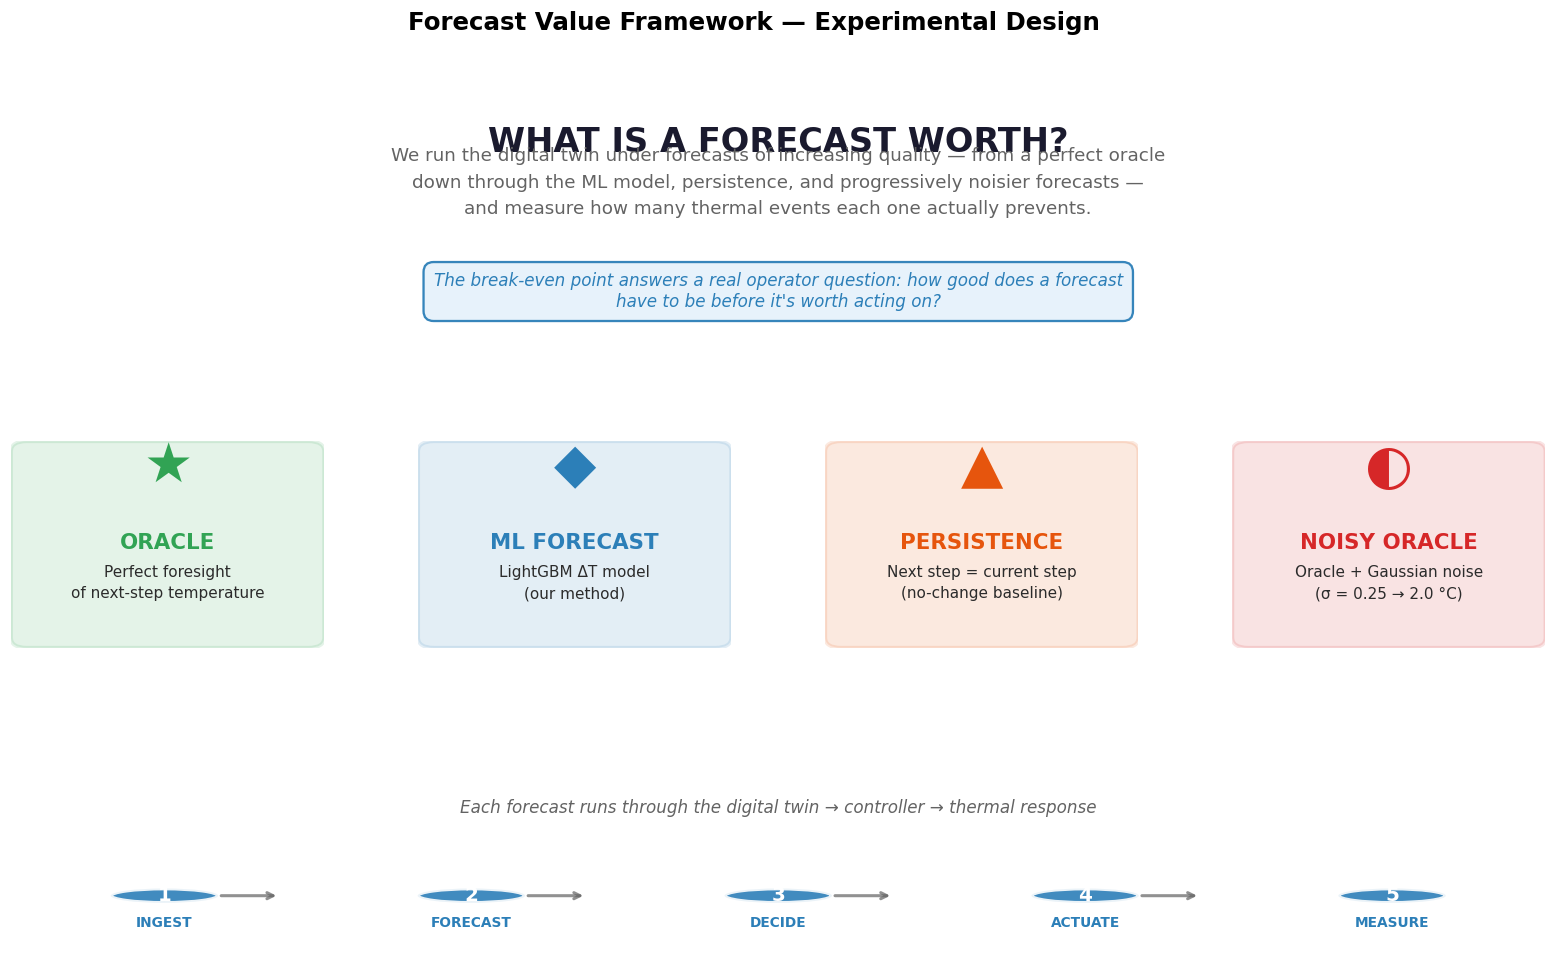

In [4]:
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(3, 4, hspace=0.55, wspace=0.30)

# ─── Header card ───
ax = fig.add_subplot(gs[0, :])
ax.axis("off")
ax.text(0.5, 0.85,
        "WHAT IS A FORECAST WORTH?",
        ha="center", fontsize=22, fontweight="bold", color=PALETTE["navy"],
        transform=ax.transAxes)
ax.text(0.5, 0.55,
        "We run the digital twin under forecasts of increasing quality — from a perfect oracle\n"
        "down through the ML model, persistence, and progressively noisier forecasts —\n"
        "and measure how many thermal events each one actually prevents.",
        ha="center", fontsize=12, color=PALETTE["neutral"], linespacing=1.6,
        transform=ax.transAxes)
ax.text(0.5, 0.10,
        "The break-even point answers a real operator question: how good does a forecast\n"
        "have to be before it's worth acting on?",
        ha="center", fontsize=11, style="italic", color=PALETTE["primary"],
        transform=ax.transAxes,
        bbox=dict(boxstyle="round,pad=0.6", facecolor="#e6f2fb",
                  edgecolor=PALETTE["primary"], alpha=0.95, linewidth=1.5))

# ─── Ladder rungs (4 panels) ───
rungs = [
    ("ORACLE",        "Perfect foresight\nof next-step temperature",
     PALETTE["success"], "★"),
    ("ML FORECAST",   "LightGBM ΔT model\n(our method)",
     PALETTE["primary"], "◆"),
    ("PERSISTENCE",   "Next step = current step\n(no-change baseline)",
     PALETTE["accent"],  "▲"),
    ("NOISY ORACLE",  "Oracle + Gaussian noise\n(σ = 0.25 → 2.0 °C)",
     PALETTE["danger"],  "◐"),
]

for i, (name, desc, color, marker) in enumerate(rungs):
    ax = fig.add_subplot(gs[1, i])
    ax.axis("off")
    ax.add_patch(FancyBboxPatch((0.05, 0.05), 0.9, 0.9,
                                 boxstyle="round,pad=0.05",
                                 facecolor=color, alpha=0.13,
                                 edgecolor=color, linewidth=2.5,
                                 transform=ax.transAxes))
    # Big marker
    ax.text(0.5, 0.80, marker, ha="center", fontsize=36, color=color,
            fontweight="bold", transform=ax.transAxes)
    ax.text(0.5, 0.48, name, ha="center", fontsize=14, fontweight="bold",
            color=color, transform=ax.transAxes)
    ax.text(0.5, 0.24, desc, ha="center", fontsize=10, color="#2b2b2b",
            transform=ax.transAxes, linespacing=1.5)

# ─── Flow arrow ───
ax = fig.add_subplot(gs[2, :])
ax.axis("off")
ax.text(0.5, 0.75,
        "Each forecast runs through the digital twin → controller → thermal response",
        ha="center", fontsize=11, style="italic",
        color=PALETTE["neutral"], transform=ax.transAxes)

# Draw flow
y = 0.35
for i, (label, x) in enumerate([("INGEST", 0.10), ("FORECAST", 0.30),
                                  ("DECIDE", 0.50), ("ACTUATE", 0.70),
                                  ("MEASURE", 0.90)]):
    ax.add_patch(Circle((x, y), 0.035, transform=ax.transAxes,
                        facecolor=PALETTE["primary"], edgecolor="white",
                        linewidth=2.5, alpha=0.9, zorder=3))
    ax.text(x, y, str(i+1), ha="center", va="center", fontsize=13,
            fontweight="bold", color="white", transform=ax.transAxes, zorder=4)
    ax.text(x, y - 0.15, label, ha="center", fontsize=9,
            fontweight="bold", color=PALETTE["primary"], transform=ax.transAxes)
    if i < 4:
        ax.annotate("", xy=(x + 0.075, y), xytext=(x + 0.035, y),
                    xycoords="axes fraction", textcoords="axes fraction",
                    arrowprops=dict(arrowstyle="->", color=PALETTE["neutral"],
                                    lw=2, alpha=0.7))

plt.suptitle("Forecast Value Framework — Experimental Design",
             fontsize=16, fontweight="bold", y=0.98)
save_fig("01_experimental_design")
plt.show()

In [5]:
# ═══════════════════════════════════════════════════════════════════════
# FORECAST LADDER
# Each entry: (name, description, forecast_array, marker, color)
# ═══════════════════════════════════════════════════════════════════════

# Oracle: perfect next-step forecast
T_oracle = np.r_[T_obs[1:], T_obs[-1]]

# ML: our ForecastTier model
T_ml = T_hat.copy()

# Persistence: current value
T_persist = T_obs.copy()

# Noisy oracle ladder (7 noise levels)
noise_levels = [0.10, 0.25, 0.50, 0.75, 1.00, 1.50, 2.00]
rng = np.random.default_rng(42)
noisy_oracles = {}
for sigma in noise_levels:
    noise = rng.normal(0, sigma, len(T_oracle))
    noisy_oracles[sigma] = T_oracle + noise

# ─── Compute MAE for each forecast ───
def forecast_mae(forecast):
    """MAE of predicting T(t+1) using the forecast array."""
    return float(np.abs(forecast[:-1] - T_oracle[:-1]).mean())

ladder = []
ladder.append({"name": "Oracle",       "forecast": T_oracle,  "sigma": 0.0,
               "marker": "★", "color": PALETTE["success"]})
ladder.append({"name": "ML Forecast",  "forecast": T_ml,      "sigma": None,
               "marker": "◆", "color": PALETTE["primary"]})
ladder.append({"name": "Persistence",  "forecast": T_persist, "sigma": None,
               "marker": "▲", "color": PALETTE["accent"]})
for sigma, f in noisy_oracles.items():
    ladder.append({"name": f"Oracle + σ={sigma:.2f}",
                   "forecast": f, "sigma": sigma,
                   "marker": "◐", "color": PALETTE["danger"]})

for entry in ladder:
    entry["MAE"] = forecast_mae(entry["forecast"])

# ─── Run twin under each forecast ───
print("Running twin under all forecasts...")
for entry in ladder:
    run = simulate_control(entry["forecast"], policy="predictive",
                           margin_c=MARGIN)
    entry["run"] = run
    entry["events"] = run["events"]
    entry["degree_min"] = run["degree_min"]
    entry["pump"] = run["pump"]
    entry["events_avoided_%"]     = (1 - run["events"] / base_events) * 100
    entry["degree_min_reduction_%"] = (1 - run["degree_min"] / base_dm) * 100
    entry["pump_overhead_%"]      = (run["pump"] / base_pump - 1) * 100

# Also run reactive (acts on observed temp)
run_reactive = simulate_control(T_obs, policy="reactive", margin_c=MARGIN)
reactive_events   = run_reactive["events"]
reactive_dm       = run_reactive["degree_min"]
reactive_pump     = run_reactive["pump"]
reactive_avoided  = (1 - reactive_events / base_events) * 100
reactive_dm_red   = (1 - reactive_dm / base_dm) * 100
reactive_pump_oh  = (reactive_pump / base_pump - 1) * 100

print(f"\nLadder results ({len(ladder)} forecasts):")
print(f"{'Name':<22} {'MAE (°C)':>10} {'Events':>8} {'Avoided %':>10} {'Pump OH %':>10}")
print("-" * 66)
for e in sorted(ladder, key=lambda x: x["MAE"]):
    print(f"{e['name']:<22} {e['MAE']:>10.3f} {e['events']:>8} "
          f"{e['events_avoided_%']:>10.1f} {e['pump_overhead_%']:>10.1f}")
print(f"{'Reactive (no forecast)':<22} {'n/a':>10} {reactive_events:>8} "
      f"{reactive_avoided:>10.1f} {reactive_pump_oh:>10.1f}")

Running twin under all forecasts...

Ladder results (10 forecasts):
Name                     MAE (°C)   Events  Avoided %  Pump OH %
------------------------------------------------------------------
Oracle                      0.000       19       85.6       39.1
Oracle + σ=0.10             0.080       19       85.6       38.8
Oracle + σ=0.25             0.200       19       85.6       39.6
Oracle + σ=0.50             0.401       16       87.9       40.8
Oracle + σ=0.75             0.600       16       87.9       41.0
Oracle + σ=1.00             0.799       18       86.4       41.7
Persistence                 0.822       21       84.1       39.1
ML Forecast                 0.831       30       77.3       36.7
Oracle + σ=1.50             1.198       20       84.8       41.9
Oracle + σ=2.00             1.579       14       89.4       43.2
Reactive (no forecast)        n/a       21       84.1       39.1


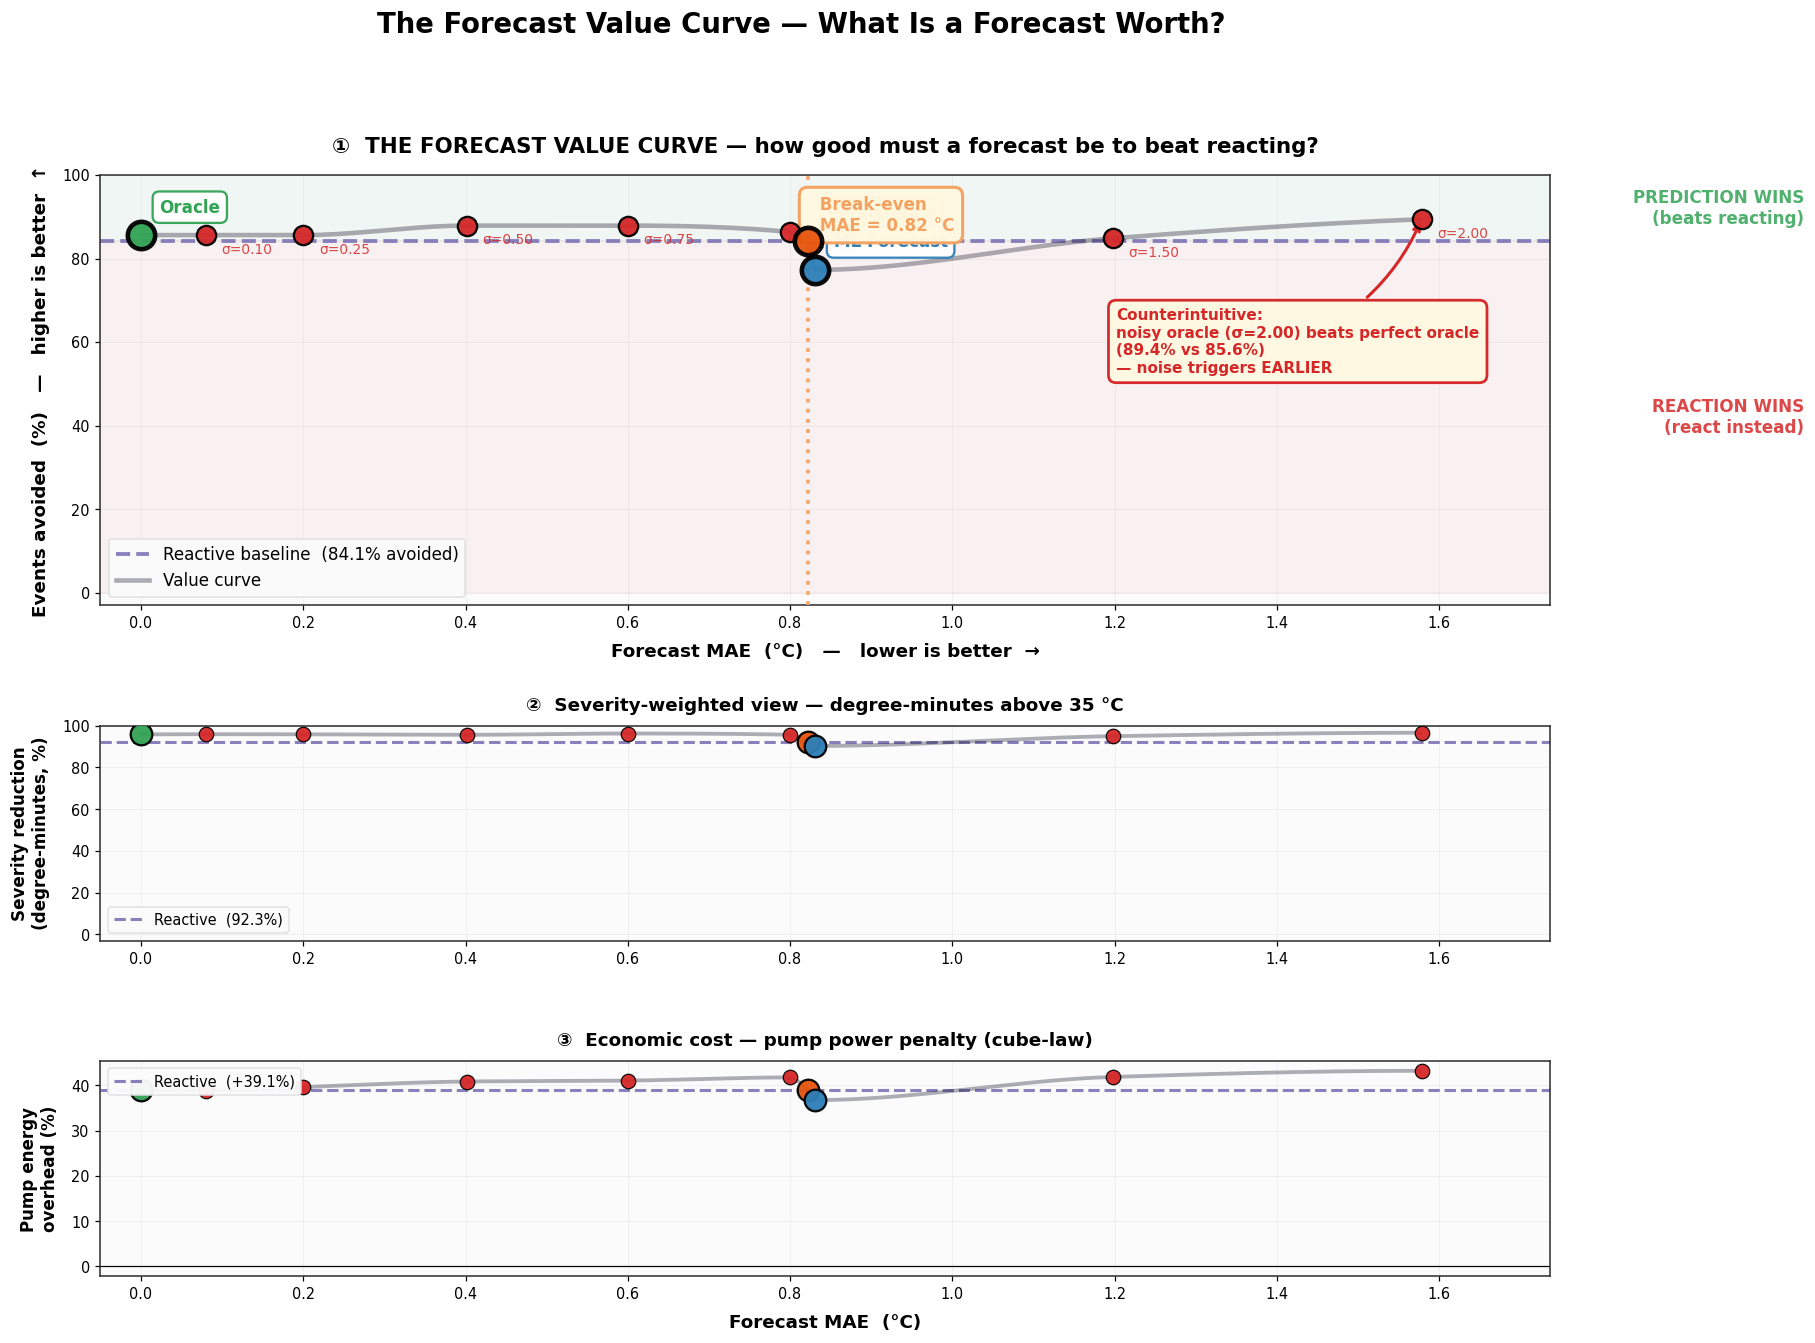


FORECAST VALUE CURVE — key numbers
Break-even forecast MAE : 0.82 °C
Reactive policy         : 84.1% events avoided  (+39.1% pump)
  [✓] Oracle                 MAE=0.000  avoided=85.6%  pump=+39.1%
  [✓] Oracle + σ=0.10        MAE=0.080  avoided=85.6%  pump=+38.8%
  [✓] Oracle + σ=0.25        MAE=0.200  avoided=85.6%  pump=+39.6%
  [✓] Oracle + σ=0.50        MAE=0.401  avoided=87.9%  pump=+40.8%
  [✓] Oracle + σ=0.75        MAE=0.600  avoided=87.9%  pump=+41.0%
  [✓] Oracle + σ=1.00        MAE=0.799  avoided=86.4%  pump=+41.7%
  [ ] Persistence            MAE=0.822  avoided=84.1%  pump=+39.1%
  [ ] ML Forecast            MAE=0.831  avoided=77.3%  pump=+36.7%
  [✓] Oracle + σ=1.50        MAE=1.198  avoided=84.8%  pump=+41.9%
  [✓] Oracle + σ=2.00        MAE=1.579  avoided=89.4%  pump=+43.2%


In [6]:
# ═══════════════════════════════════════════════════════════════════════
# THE FORECAST VALUE CURVE
# X-axis: forecast MAE (°C)
# Y-axis: events avoided (%)
# Reveals the break-even MAE where prediction beats reaction
# ═══════════════════════════════════════════════════════════════════════

# Sort ladder by MAE
ladder_sorted = sorted(ladder, key=lambda x: x["MAE"])
maes       = [e["MAE"] for e in ladder_sorted]
avoided    = [e["events_avoided_%"] for e in ladder_sorted]
dm_reduce  = [e["degree_min_reduction_%"] for e in ladder_sorted]
pump_oh    = [e["pump_overhead_%"] for e in ladder_sorted]
names      = [e["name"] for e in ladder_sorted]
colors     = [e["color"] for e in ladder_sorted]
markers    = [e["marker"] for e in ladder_sorted]

# ═══════════════════════════════════════════════════════════════════════
# FIGURE — 3 stacked panels
# ═══════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(17, 13))
gs = fig.add_gridspec(3, 1, height_ratios=[2.0, 1.0, 1.0], hspace=0.42)

# ─────────────────────────────────────────────────────────────────────
# TOP PANEL — Events avoided vs forecast MAE
# ─────────────────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0])

# Break-even line (reactive policy reference)
ax.axhline(reactive_avoided, color=PALETTE["purple"], ls="--", lw=2.5,
           alpha=0.85, zorder=2,
           label=f"Reactive baseline  ({reactive_avoided:.1f}% avoided)")

# Shaded regions
ax.axhspan(reactive_avoided, 100, color=PALETTE["success"], alpha=0.05, zorder=0)
ax.axhspan(0, reactive_avoided, color=PALETTE["danger"], alpha=0.05, zorder=0)

# Annotate regions
ax.text(2.05, (reactive_avoided + 100) / 2,
        "PREDICTION WINS\n(beats reacting)",
        fontsize=11, fontweight="bold", color=PALETTE["success"], ha="right",
        va="center", alpha=0.85)
ax.text(2.05, reactive_avoided / 2,
        "REACTION WINS\n(react instead)",
        fontsize=11, fontweight="bold", color=PALETTE["danger"], ha="right",
        va="center", alpha=0.85)

# Main curve — smooth interpolation
from scipy.interpolate import PchipInterpolator
x_smooth = np.linspace(0, max(maes) * 1.08, 200)
pchip = PchipInterpolator(maes, avoided)
y_smooth = pchip(np.clip(x_smooth, min(maes), max(maes)))
mask_extrap = (x_smooth > max(maes)) | (x_smooth < min(maes))
y_smooth = np.where(mask_extrap, np.nan, y_smooth)

ax.plot(x_smooth, y_smooth, "-", lw=3, color=PALETTE["navy"],
        alpha=0.35, zorder=2, label="Value curve")

# Scatter each forecast point (styled by type)
for i, (m, a, name, color, marker) in enumerate(zip(maes, avoided, names, colors, markers)):
    size = 320 if name in ["Oracle", "ML Forecast", "Persistence"] else 160
    edge = 3 if name in ["Oracle", "ML Forecast", "Persistence"] else 1.5
    ax.scatter(m, a, s=size, c=color, marker="o",
               edgecolor="black", linewidth=edge, zorder=5, alpha=0.95)
    # Label the big three
    if name in ["Oracle", "ML Forecast", "Persistence"]:
        offset = (12, 15)
        ax.annotate(name, (m, a), xytext=offset, textcoords="offset points",
                    fontsize=11, fontweight="bold", color=color,
                    bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                              edgecolor=color, alpha=0.95, linewidth=1.5))
    # Small labels for noisy oracle points
    elif name.startswith("Oracle +"):
        ax.annotate(name.replace("Oracle + σ=", "σ="),
                    (m, a), xytext=(10, -12), textcoords="offset points",
                    fontsize=9, color=PALETTE["danger"], alpha=0.85)

# Find break-even MAE
above = np.array(avoided) > reactive_avoided
break_even = None
if above.any() and not above.all():
    crossings = np.where(np.diff(above.astype(int)) != 0)[0]
    if len(crossings) > 0:
        idx = crossings[0]
        if idx + 1 < len(maes):
            m1, m2 = maes[idx], maes[idx + 1]
            a1, a2 = avoided[idx], avoided[idx + 1]
            t = (reactive_avoided - a1) / (a2 - a1)
            break_even = m1 + t * (m2 - m1)
            ax.axvline(break_even, color=PALETTE["gold"], ls=":", lw=2.5,
                       alpha=0.9, zorder=3)
            ax.text(break_even, max(avoided) * 0.97,
                    f"  Break-even\n  MAE = {break_even:.2f} °C",
                    fontsize=11, fontweight="bold", color=PALETTE["gold"],
                    bbox=dict(boxstyle="round,pad=0.5", facecolor="#fff8e1",
                              edgecolor=PALETTE["gold"], linewidth=2,
                              alpha=0.98))

# ─── Annotate the counterintuitive finding: noisy > accurate ───
noisy_entries = [e for e in ladder if e["name"].startswith("Oracle +")]
if noisy_entries:
    noisy_best = max(noisy_entries, key=lambda x: x["events_avoided_%"])
    oracle_avoided = ladder[0]["events_avoided_%"]
    if noisy_best["events_avoided_%"] > oracle_avoided:
        ax.annotate(
            f"Counterintuitive:\n"
            f"noisy oracle (σ={noisy_best['sigma']:.2f}) "
            f"beats perfect oracle\n"
            f"({noisy_best['events_avoided_%']:.1f}% vs {oracle_avoided:.1f}%)\n"
            f"— noise triggers EARLIER",
            xy=(noisy_best["MAE"], noisy_best["events_avoided_%"]),
            xytext=(-200, -100), textcoords="offset points",
            fontsize=10, fontweight="bold", color=PALETTE["danger"],
            bbox=dict(boxstyle="round,pad=0.5", facecolor="#fff8e1",
                      edgecolor=PALETTE["danger"], linewidth=1.8, alpha=0.98),
            arrowprops=dict(arrowstyle="->", color=PALETTE["danger"], lw=2,
                            connectionstyle="arc3,rad=0.2"),
        )

ax.set_xlabel("Forecast MAE  (°C)   —   lower is better  →",
              fontsize=12, fontweight="bold")
ax.set_ylabel("Events avoided  (%)   —   higher is better  ↑",
              fontsize=12, fontweight="bold")
ax.set_title("①  THE FORECAST VALUE CURVE — how good must a forecast be to beat reacting?",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlim(-0.05, max(maes) * 1.10)
ax.set_ylim(-3, 100)
ax.legend(loc="lower left", fontsize=11, framealpha=0.98)
ax.grid(True, alpha=0.3)

# ─────────────────────────────────────────────────────────────────────
# MIDDLE PANEL — Degree-minutes reduction
# ─────────────────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[1], sharex=ax)

ax.axhline(reactive_dm_red, color=PALETTE["purple"], ls="--", lw=2,
           alpha=0.85, label=f"Reactive  ({reactive_dm_red:.1f}%)")

y_smooth_dm = PchipInterpolator(maes, dm_reduce)(np.clip(x_smooth, min(maes), max(maes)))
y_smooth_dm = np.where(mask_extrap, np.nan, y_smooth_dm)
ax.plot(x_smooth, y_smooth_dm, "-", lw=2.5, color=PALETTE["navy"], alpha=0.35)

for m, d, name, color in zip(maes, dm_reduce, names, colors):
    size = 200 if name in ["Oracle", "ML Forecast", "Persistence"] else 90
    ax.scatter(m, d, s=size, c=color, edgecolor="black",
               linewidth=1.5 if name in ["Oracle", "ML Forecast", "Persistence"] else 0.8,
               zorder=5, alpha=0.95)

ax.set_ylabel("Severity reduction\n(degree-minutes, %)",
              fontsize=11, fontweight="bold")
ax.set_title("②  Severity-weighted view — degree-minutes above 35 °C",
             fontsize=12, fontweight="bold", pad=10)
ax.legend(loc="lower left", fontsize=9.5)
ax.set_ylim(-3, 100)
ax.grid(True, alpha=0.3)

# ─────────────────────────────────────────────────────────────────────
# BOTTOM PANEL — Pump energy overhead
# ─────────────────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[2], sharex=ax)

ax.axhline(reactive_pump_oh, color=PALETTE["purple"], ls="--", lw=2,
           alpha=0.85, label=f"Reactive  (+{reactive_pump_oh:.1f}%)")
ax.axhline(0, color="black", lw=0.8)

y_smooth_po = PchipInterpolator(maes, pump_oh)(np.clip(x_smooth, min(maes), max(maes)))
y_smooth_po = np.where(mask_extrap, np.nan, y_smooth_po)
ax.plot(x_smooth, y_smooth_po, "-", lw=2.5, color=PALETTE["navy"], alpha=0.35)

for m, p, name, color in zip(maes, pump_oh, names, colors):
    size = 200 if name in ["Oracle", "ML Forecast", "Persistence"] else 90
    ax.scatter(m, p, s=size, c=color, edgecolor="black",
               linewidth=1.5 if name in ["Oracle", "ML Forecast", "Persistence"] else 0.8,
               zorder=5, alpha=0.95)

ax.set_xlabel("Forecast MAE  (°C)", fontsize=12, fontweight="bold")
ax.set_ylabel("Pump energy\noverhead (%)", fontsize=11, fontweight="bold")
ax.set_title("③  Economic cost — pump power penalty (cube-law)",
             fontsize=12, fontweight="bold", pad=10)
ax.legend(loc="upper left", fontsize=9.5)
ax.grid(True, alpha=0.3)

plt.suptitle("The Forecast Value Curve — What Is a Forecast Worth?",
             fontsize=18, fontweight="bold", y=0.995)
save_fig("02_forecast_value_curve")
plt.show()

# Print summary
print("\n" + "=" * 72)
print("FORECAST VALUE CURVE — key numbers")
print("=" * 72)
if break_even is not None:
    print(f"Break-even forecast MAE : {break_even:.2f} °C")
print(f"Reactive policy         : {reactive_avoided:.1f}% events avoided  "
      f"(+{reactive_pump_oh:.1f}% pump)")
for e in ladder_sorted:
    marker = "✓" if e["events_avoided_%"] > reactive_avoided else " "
    print(f"  [{marker}] {e['name']:<22} MAE={e['MAE']:.3f}  "
          f"avoided={e['events_avoided_%']:.1f}%  pump=+{e['pump_overhead_%']:.1f}%")

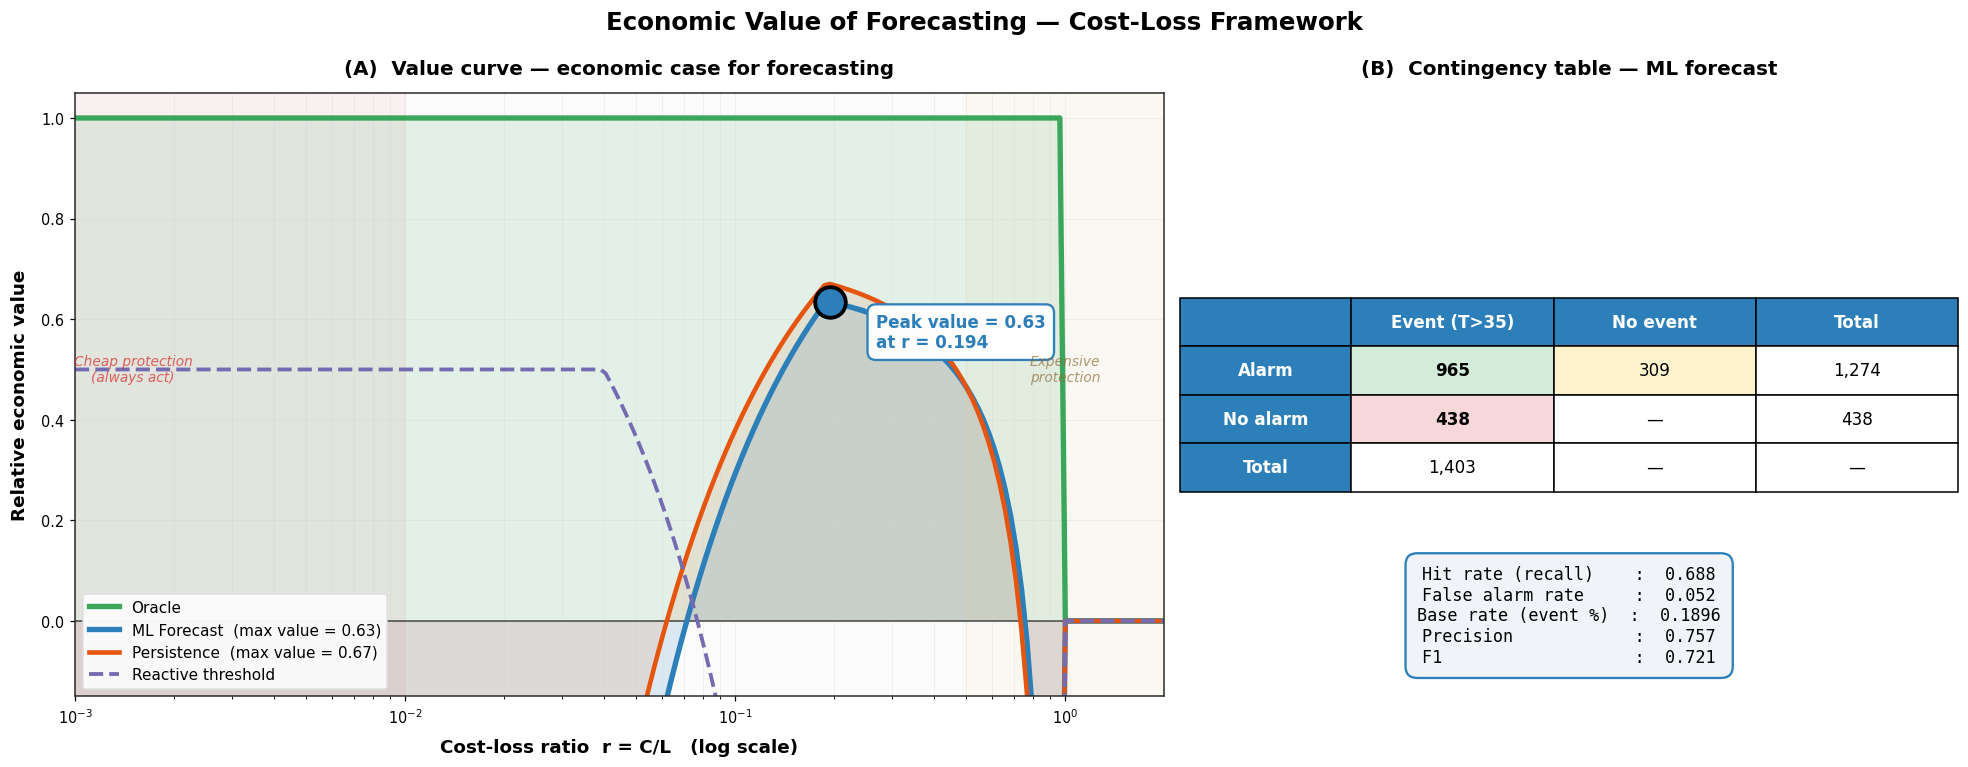


COST-LOSS VALUE ANALYSIS
Oracle                H=1.000  F=0.000  max value = 1.000 at r = 0.0010
ML Forecast           H=0.688  F=0.052  max value = 0.635 at r = 0.1943
Persistence           H=0.734  F=0.062  max value = 0.670 at r = 0.1943


In [7]:
# ══════════════════════════════════════════════════════════════════════
# COST-LOSS VALUE FRAMEWORK (Richardson 2000, from weather forecasting)
# ══════════════════════════════════════════════════════════════════════

# Compute hit rate, false alarm rate, miss rate for each forecast
def contingency_metrics(forecast, threshold=HIGH_THRESH - MARGIN):
    """Compute hit rate, FAR, and base rate for a threshold decision rule."""
    decision = forecast[:-1] >= threshold
    truth    = T_oracle[:-1] >= threshold

    hits        = (decision & truth).sum()
    misses      = (~decision & truth).sum()
    false_alarm = (decision & ~truth).sum()
    correct_rej = (~decision & ~truth).sum()

    hit_rate  = hits / max(hits + misses, 1)
    far       = false_alarm / max(false_alarm + correct_rej, 1)
    base_rate = truth.mean()

    return {"H": hit_rate, "F": far, "s": base_rate,
            "n_hits": int(hits), "n_miss": int(misses),
            "n_fa": int(false_alarm)}

# Compute for each forecast
for entry in ladder:
    entry["contingency"] = contingency_metrics(entry["forecast"])

# ─── Value function (Richardson 2000) — VECTORIZED ───
def forecast_value(H, F, s, r):
    """Value of a forecast at cost-loss ratio r. Fully vectorized."""
    r = np.asarray(r, dtype=float)
    E_forecast = r * (H * s + F * (1 - s)) + (1 - H) * s
    E_always   = r
    E_never    = s
    E_perfect  = r * s
    E_standard = np.minimum(E_always, E_never)
    denom      = E_standard - E_perfect
    # Vectorized guard: where denom <= 0, value is 0
    with np.errstate(divide="ignore", invalid="ignore"):
        val = np.where(denom > 1e-12,
                       (E_standard - E_forecast) / np.maximum(denom, 1e-12),
                       0.0)
    return np.clip(val, -1, 1)

# Cost-loss ratio range
r_grid = np.logspace(-3, 0.3, 200)  # 0.001 to 2

fig, axes = plt.subplots(1, 2, figsize=(18, 7),
                          gridspec_kw={"width_ratios": [1.4, 1.0]})

# ─── (A) Value curves ───
ax = axes[0]

# Oracle (perfect)
H_o = ladder[0]["contingency"]["H"];  F_o = ladder[0]["contingency"]["F"]
s_o = ladder[0]["contingency"]["s"]
val_oracle = forecast_value(H_o, F_o, s_o, r_grid)

# ML
ml_idx = [i for i, e in enumerate(ladder) if e["name"] == "ML Forecast"][0]
H_m = ladder[ml_idx]["contingency"]["H"];  F_m = ladder[ml_idx]["contingency"]["F"]
s_m = ladder[ml_idx]["contingency"]["s"]
val_ml = forecast_value(H_m, F_m, s_m, r_grid)

# Persistence
per_idx = [i for i, e in enumerate(ladder) if e["name"] == "Persistence"][0]
H_p = ladder[per_idx]["contingency"]["H"];  F_p = ladder[per_idx]["contingency"]["F"]
s_p = ladder[per_idx]["contingency"]["s"]
val_persist = forecast_value(H_p, F_p, s_p, r_grid)

# Reactive reference
H_r = 1.0;  F_r = 0.5
val_reactive = forecast_value(H_r, F_r, 0.04, r_grid)

# Plot
ax.axhline(0, color="black", lw=1, alpha=0.6)

ax.fill_between(r_grid, 0, val_oracle, alpha=0.12, color=PALETTE["success"])
ax.plot(r_grid, val_oracle, "-", lw=3.5, color=PALETTE["success"],
        label=f"Oracle", alpha=0.95)
ax.fill_between(r_grid, 0, val_ml, alpha=0.15, color=PALETTE["primary"])
ax.plot(r_grid, val_ml, "-", lw=3.5, color=PALETTE["primary"],
        label=f"ML Forecast  (max value = {val_ml.max():.2f})")
ax.fill_between(r_grid, 0, val_persist, alpha=0.10, color=PALETTE["accent"])
ax.plot(r_grid, val_persist, "-", lw=3.0, color=PALETTE["accent"],
        label=f"Persistence  (max value = {val_persist.max():.2f})")
ax.plot(r_grid, val_reactive, "--", lw=2.5, color=PALETTE["purple"],
        label="Reactive threshold")

# Mark ML peak
peak_idx = np.argmax(val_ml)
ax.scatter(r_grid[peak_idx], val_ml[peak_idx], s=400, c=PALETTE["primary"],
           edgecolor="black", linewidth=2.5, zorder=10)
ax.annotate(f"Peak value = {val_ml[peak_idx]:.2f}\nat r = {r_grid[peak_idx]:.3f}",
            (r_grid[peak_idx], val_ml[peak_idx]),
            xytext=(30, -30), textcoords="offset points",
            fontsize=11, fontweight="bold", color=PALETTE["primary"],
            bbox=dict(boxstyle="round,pad=0.5", facecolor="white",
                      edgecolor=PALETTE["primary"], linewidth=1.5, alpha=0.98),
            arrowprops=dict(arrowstyle="->", color=PALETTE["primary"], lw=2))

ax.set_xscale("log")
ax.set_xlabel("Cost-loss ratio  r = C/L   (log scale)",
              fontsize=12, fontweight="bold")
ax.set_ylabel("Relative economic value",
              fontsize=12, fontweight="bold")
ax.set_title("(A)  Value curve — economic case for forecasting",
             fontsize=13, fontweight="bold", pad=12)
ax.set_ylim(-0.15, 1.05)
ax.set_xlim(r_grid.min(), r_grid.max())
ax.legend(loc="lower left", fontsize=10, framealpha=0.98)
ax.grid(True, alpha=0.3, which="both")

# Annotate regions
ax.axvspan(r_grid.min(), 0.01, color=PALETTE["danger"], alpha=0.05)
ax.text(0.0015, 0.5, "Cheap protection\n(always act)",
        fontsize=9, ha="center", va="center", color=PALETTE["danger"],
        alpha=0.7, style="italic")
ax.axvspan(0.5, r_grid.max(), color=PALETTE["warning"], alpha=0.05)
ax.text(1.0, 0.5, "Expensive\nprotection",
        fontsize=9, ha="center", va="center", color="#8a6d3b",
        alpha=0.7, style="italic")

# ─── (B) Contingency table ───
ax = axes[1]
ax.axis("off")
ax.set_title("(B)  Contingency table — ML forecast",
             fontsize=13, fontweight="bold", pad=12)

con = ladder[ml_idx]["contingency"]
table_data = [
    ["", "Event (T>35)", "No event", "Total"],
    ["Alarm",   f"{con['n_hits']:,}",   f"{con['n_fa']:,}",   f"{con['n_hits']+con['n_fa']:,}"],
    ["No alarm", f"{con['n_miss']:,}", "—",                  f"{con['n_miss']:,}"],
    ["Total",   f"{con['n_hits']+con['n_miss']:,}", "—",     "—"],
]
table = ax.table(cellText=table_data, loc="center", cellLoc="center",
                 colWidths=[0.22, 0.26, 0.26, 0.26])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.6)

for i in range(4):
    for j in range(4):
        cell = table[(i, j)]
        if i == 0 or j == 0:
            cell.set_facecolor(PALETTE["primary"])
            cell.set_text_props(color="white", fontweight="bold")
        elif i == 1 and j == 1:
            cell.set_facecolor("#d4edda"); cell.set_text_props(fontweight="bold")
        elif i == 2 and j == 1:
            cell.set_facecolor("#f8d7da"); cell.set_text_props(fontweight="bold")
        elif i == 1 and j == 2:
            cell.set_facecolor("#fff3cd")

precision = con['n_hits'] / max(con['n_hits'] + con['n_fa'], 1)
f1_score = 2 * con['H'] * precision / max(con['H'] + precision, 1e-9)

metrics_text = (
    f"Hit rate (recall)    :  {con['H']:.3f}\n"
    f"False alarm rate     :  {con['F']:.3f}\n"
    f"Base rate (event %)  :  {con['s']:.4f}\n"
    f"Precision            :  {precision:.3f}\n"
    f"F1                   :  {f1_score:.3f}"
)
ax.text(0.5, 0.05, metrics_text, transform=ax.transAxes,
        fontsize=11, family="monospace", ha="center", va="bottom",
        bbox=dict(boxstyle="round,pad=0.7", facecolor="#f0f4f8",
                  edgecolor=PALETTE["primary"], linewidth=1.5))

plt.suptitle("Economic Value of Forecasting — Cost-Loss Framework",
             fontsize=16, fontweight="bold", y=0.99)
plt.tight_layout()
save_fig("03_cost_loss_value")
plt.show()

print("\n" + "=" * 72)
print("COST-LOSS VALUE ANALYSIS")
print("=" * 72)
for e in [ladder[0], ladder[ml_idx], ladder[per_idx]]:
    con = e["contingency"]
    val_curve = forecast_value(con["H"], con["F"], con["s"], r_grid)
    print(f"{e['name']:<20}  H={con['H']:.3f}  F={con['F']:.3f}  "
          f"max value = {val_curve.max():.3f} at r = {r_grid[val_curve.argmax()]:.4f}")

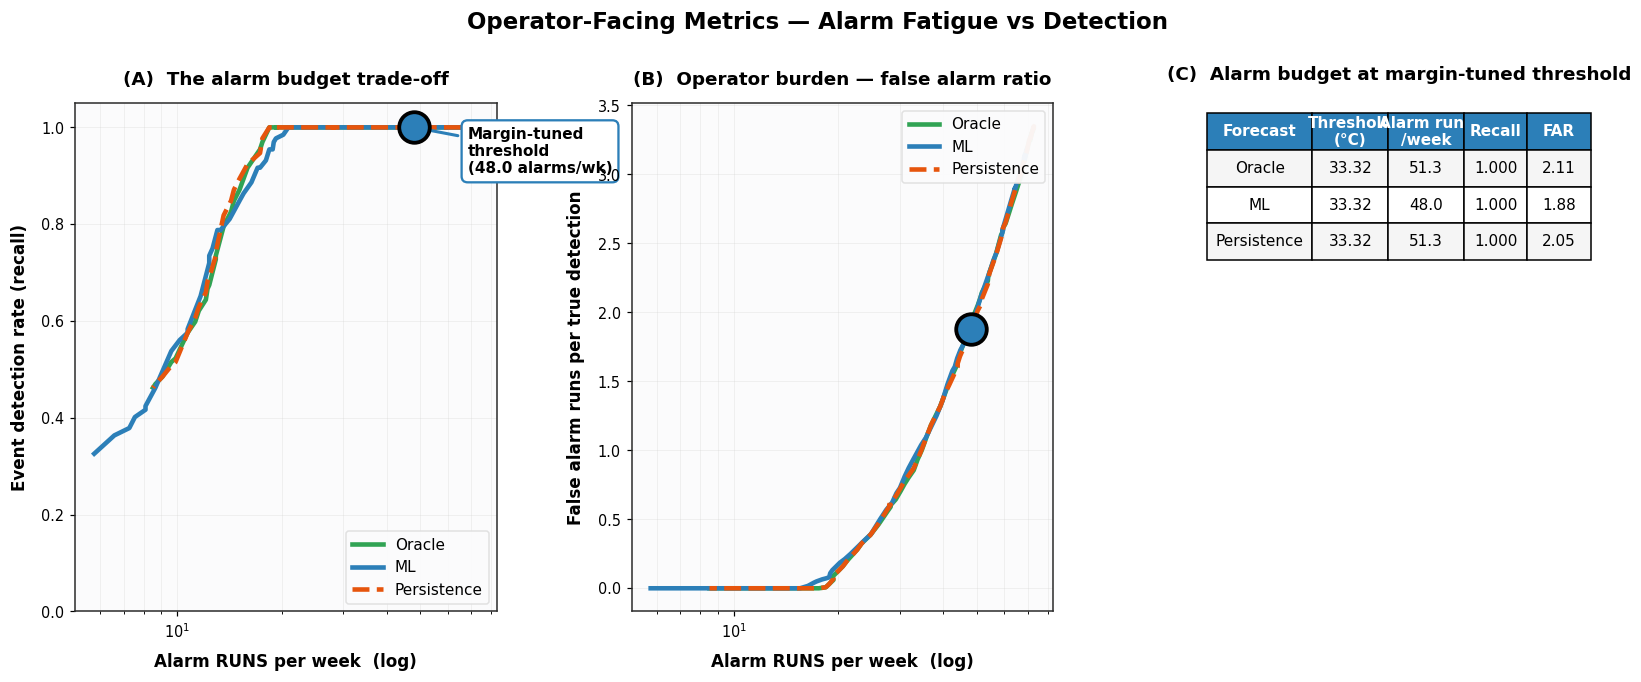


ALARM BUDGET — operator-facing metrics (alarm RUNS, not timesteps)
Oracle          threshold=33.32°C  alarm runs/week=51.3  recall=1.000  false runs/detection=2.11
ML              threshold=33.32°C  alarm runs/week=48.0  recall=1.000  false runs/detection=1.88
Persistence     threshold=33.32°C  alarm runs/week=51.3  recall=1.000  false runs/detection=2.05


In [8]:
# ═══════════════════════════════════════════════════════════════════════
# ALARM BUDGET ANALYSIS
# Counts distinct ALARM RUNS (onsets), not timesteps — matches operator
# experience of "how many times per week does the system alert me?"
# ═══════════════════════════════════════════════════════════════════════

test_weeks = (test["timestamp"].max() - test["timestamp"].min()).days / 7

def alarm_budget_curve(forecast, thresholds):
    """Sweep thresholds, compute alarm rates and detection."""
    true_event = (T_oracle >= HIGH_THRESH).astype(int)
    results = []

    # Precompute true event windows
    event_windows = []
    start = None
    for i, t in enumerate(true_event):
        if t == 1 and start is None:
            start = i
        elif t == 0 and start is not None:
            event_windows.append((start, i))
            start = None
    if start is not None:
        event_windows.append((start, len(true_event)))

    for thr in thresholds:
        alarm = (forecast[:-1] >= thr).astype(int)

        # Count ALARM RUNS (onsets), not timesteps
        onsets = np.flatnonzero(alarm[1:] & ~alarm[:-1]) + 1
        if alarm[0]:
            onsets = np.r_[0, onsets]

        # For each true event, does an alarm onset fall within [s-2, e+2]?
        detected = 0
        for (s, e) in event_windows:
            lo, hi = max(0, s-2), min(len(alarm), e+3)
            if alarm[lo:hi].any():
                detected += 1
        recall = detected / max(len(event_windows), 1)

        # False alarm runs: onsets not near a true event
        false_onsets = 0
        for onset in onsets:
            window = true_event[max(0, onset-3):min(len(true_event), onset+4)]
            if not window.any():
                false_onsets += 1

        alarms_per_week    = len(onsets) / test_weeks
        fa_onsets_per_week = false_onsets / test_weeks

        results.append({
            "threshold": thr,
            "recall": recall,
            "alarms_per_week": alarms_per_week,
            "false_alarms_per_week": fa_onsets_per_week,
            "total_events": len(event_windows),
            "detected": detected,
            "false_alarms": false_onsets,
            "n_onsets": len(onsets),
        })
    return pd.DataFrame(results)

# ─── Threshold sweep ───
thr_grid = np.linspace(HIGH_THRESH - 3.0, HIGH_THRESH + 1.0, 80)

budget_ml      = alarm_budget_curve(T_ml,      thr_grid)
budget_oracle  = alarm_budget_curve(T_oracle,  thr_grid)
budget_persist = alarm_budget_curve(T_persist, thr_grid)

# ═══════════════════════════════════════════════════════════════════════
# FIGURE — 3 panels
# ═══════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(18, 6))
gs = fig.add_gridspec(1, 3, wspace=0.32)

# ─── (A) Recall vs alarms-per-week ───
ax = fig.add_subplot(gs[0, 0])
for name, budget, color, ls in [("Oracle", budget_oracle, PALETTE["success"], "-"),
                                 ("ML", budget_ml, PALETTE["primary"], "-"),
                                 ("Persistence", budget_persist, PALETTE["accent"], "--")]:
    ax.plot(budget["alarms_per_week"], budget["recall"], ls, lw=3,
            color=color, label=name)

# Highlight ML at margin-based threshold
ml_thr_idx = (budget_ml["threshold"] - (HIGH_THRESH - MARGIN)).abs().idxmin()
ml_point = budget_ml.loc[ml_thr_idx]
ax.scatter(ml_point["alarms_per_week"], ml_point["recall"], s=400,
           c=PALETTE["primary"], edgecolor="black", linewidth=2.5, zorder=10)
ax.annotate(f"Margin-tuned\nthreshold\n({ml_point['alarms_per_week']:.1f} alarms/wk)",
            (ml_point["alarms_per_week"], ml_point["recall"]),
            xytext=(35, -30), textcoords="offset points",
            fontsize=10, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                      edgecolor=PALETTE["primary"], linewidth=1.5),
            arrowprops=dict(arrowstyle="->", color=PALETTE["primary"], lw=2))

ax.set_xscale("log")
ax.set_xlabel("Alarm RUNS per week  (log)", fontsize=11, fontweight="bold")
ax.set_ylabel("Event detection rate (recall)", fontsize=11, fontweight="bold")
ax.set_title("(A)  The alarm budget trade-off", fontsize=12, fontweight="bold")
ax.set_ylim(0, 1.05)
ax.legend(loc="lower right", fontsize=10)
ax.grid(True, alpha=0.3, which="both")

# ─── (B) False alarms per true detection ───
ax = fig.add_subplot(gs[0, 1])
for name, budget, color, ls in [("Oracle", budget_oracle, PALETTE["success"], "-"),
                                 ("ML", budget_ml, PALETTE["primary"], "-"),
                                 ("Persistence", budget_persist, PALETTE["accent"], "--")]:
    ratio = budget["false_alarms"] / np.maximum(budget["detected"], 1)
    ax.plot(budget["alarms_per_week"], ratio, ls, lw=3,
            color=color, label=name)

ax.scatter(ml_point["alarms_per_week"],
           ml_point["false_alarms"] / max(ml_point["detected"], 1),
           s=400, c=PALETTE["primary"], edgecolor="black", linewidth=2.5, zorder=10)
ax.set_xscale("log")
ax.set_xlabel("Alarm RUNS per week  (log)", fontsize=11, fontweight="bold")
ax.set_ylabel("False alarm runs per true detection", fontsize=11, fontweight="bold")
ax.set_title("(B)  Operator burden — false alarm ratio", fontsize=12, fontweight="bold")
ax.legend(loc="upper right", fontsize=10)
ax.grid(True, alpha=0.3, which="both")

# ─── (C) Alarm table at chosen threshold ───
ax = fig.add_subplot(gs[0, 2])
ax.axis("off")

table_rows = [["Forecast", "Threshold\n(°C)", "Alarm runs\n/week", "Recall", "FAR"]]
for name, budget, color in [("Oracle", budget_oracle, PALETTE["success"]),
                             ("ML", budget_ml, PALETTE["primary"]),
                             ("Persistence", budget_persist, PALETTE["accent"])]:
    idx = (budget["threshold"] - (HIGH_THRESH - MARGIN)).abs().idxmin()
    row = budget.loc[idx]
    table_rows.append([
        name,
        f"{row['threshold']:.2f}",
        f"{row['alarms_per_week']:.1f}",
        f"{row['recall']:.3f}",
        f"{row['false_alarms']/max(row['total_events'],1):.2f}",
    ])

table = ax.table(cellText=table_rows, loc="upper center", cellLoc="center",
                 colWidths=[0.25, 0.18, 0.18, 0.15, 0.15])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.0)

for i in range(len(table_rows)):
    for j in range(5):
        cell = table[(i, j)]
        if i == 0:
            cell.set_facecolor(PALETTE["primary"])
            cell.set_text_props(color="white", fontweight="bold")
        elif i % 2 == 1:
            cell.set_facecolor("#f5f5f5")

ax.set_title("(C)  Alarm budget at margin-tuned threshold",
             fontsize=12, fontweight="bold", pad=15)

plt.suptitle("Operator-Facing Metrics — Alarm Fatigue vs Detection",
             fontsize=15, fontweight="bold", y=1.02)
save_fig("04_alarm_budget")
plt.show()

print("\n" + "=" * 72)
print("ALARM BUDGET — operator-facing metrics (alarm RUNS, not timesteps)")
print("=" * 72)
for name, budget in [("Oracle", budget_oracle), ("ML", budget_ml),
                      ("Persistence", budget_persist)]:
    idx = (budget["threshold"] - (HIGH_THRESH - MARGIN)).abs().idxmin()
    row = budget.loc[idx]
    print(f"{name:<14}  threshold={row['threshold']:.2f}°C  "
          f"alarm runs/week={row['alarms_per_week']:.1f}  "
          f"recall={row['recall']:.3f}  "
          f"false runs/detection={row['false_alarms']/max(row['detected'],1):.2f}")

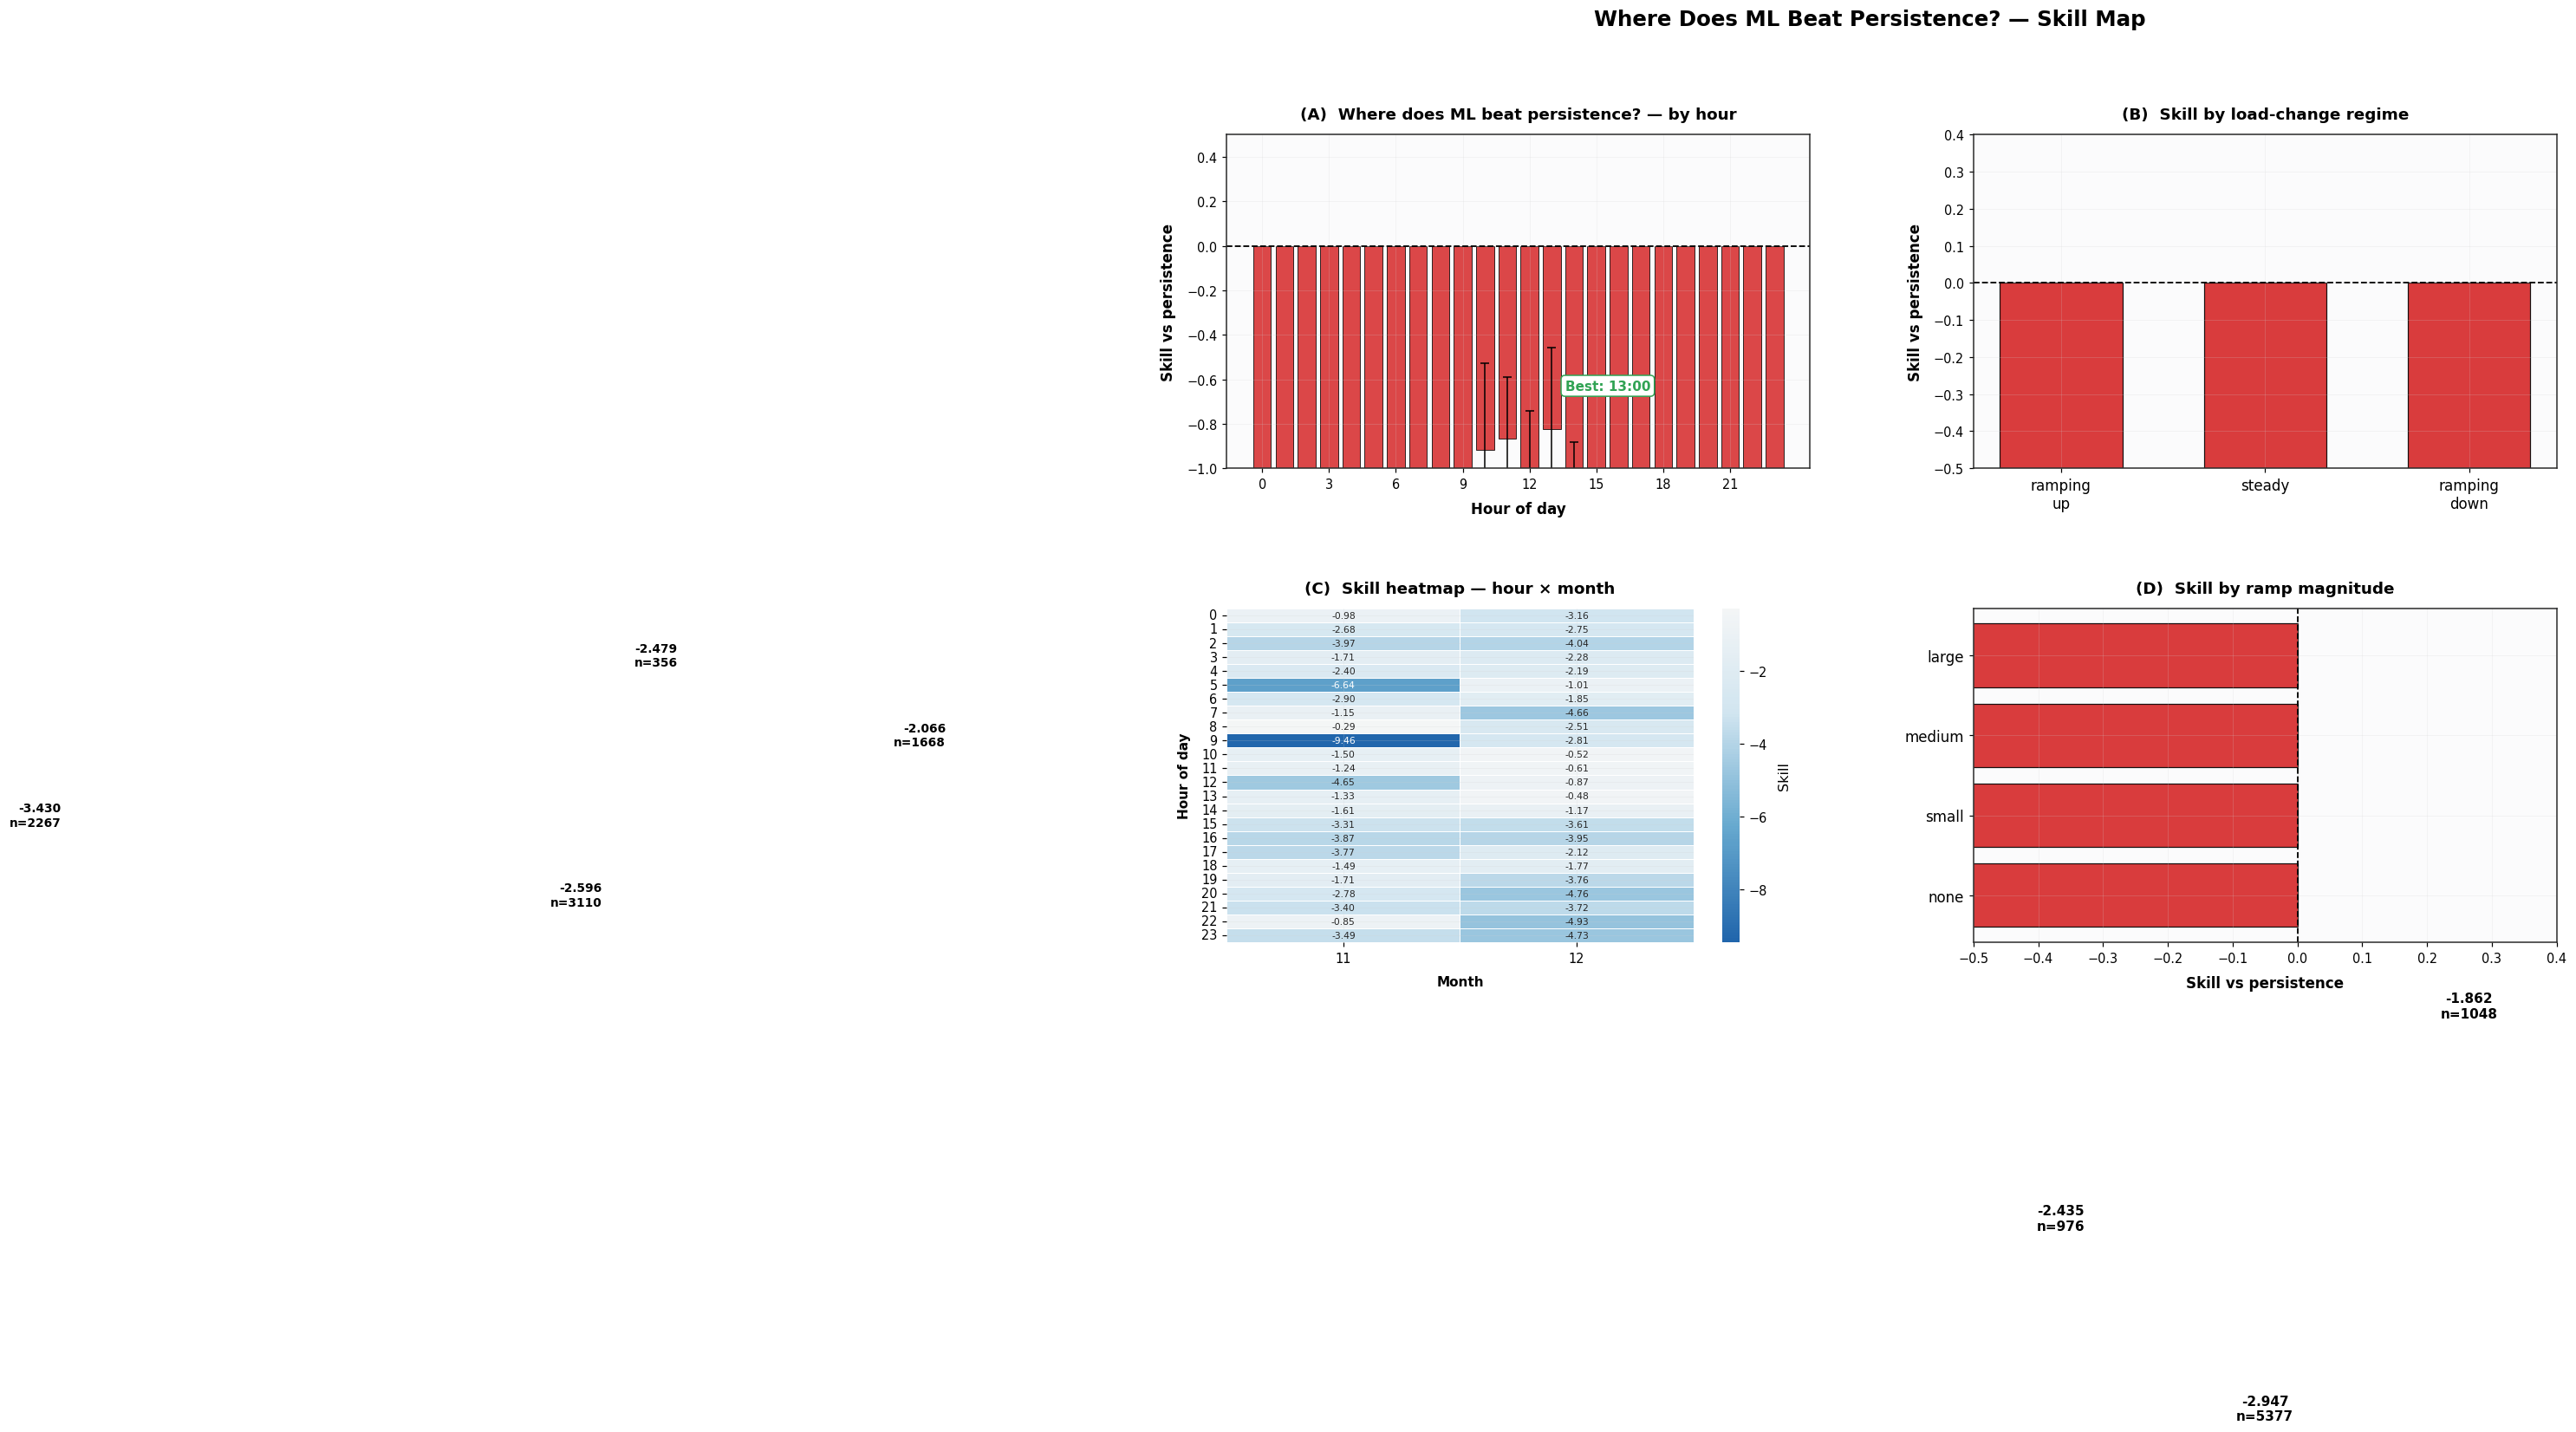


PERSISTENCE SKILL MAP — key findings
Overall skill: -2.726   (n=7,401 steps)
  Best hour  : 13:00 → -0.825
  Worst hour : 09:00 → -5.483
  Ramp up    : -2.435
  Steady     : -2.947
  Ramp down  : -1.862
  Positive skill fraction: 47.8% of steps


In [9]:
# ═══════════════════════════════════════════════════════════════════════
# PERSISTENCE SKILL MAP
# Skill = 1 - MAE_model / MAE_persistence
# Sliced by regime (hour, load-change, ramp direction, month)
# ═══════════════════════════════════════════════════════════════════════

# Build a DataFrame with all relevant features
df = pd.DataFrame({
    "timestamp":       test["timestamp"].values,
    "T_obs":           T_obs,
    "T_ml":            T_ml,
    "T_persist":       T_persist,
    "T_oracle":        T_oracle,
    "compute_power":   test["compute_power"].values,
})

# ── FIX: error arrays must match df length (7402), pad last row with NaN ──
n = len(df)
err_ml      = np.full(n, np.nan)
err_persist = np.full(n, np.nan)
err_ml[:-1]      = np.abs(T_ml[:-1]      - T_oracle[:-1])
err_persist[:-1] = np.abs(T_persist[:-1] - T_oracle[:-1])

df["T_ml_err"]      = err_ml
df["T_persist_err"] = err_persist
df["dT_dt"]         = df["T_obs"].diff().fillna(0)
df["compute_delta"] = df["compute_power"].diff().fillna(0)

# Regime features
df["hour"]  = pd.to_datetime(df["timestamp"]).dt.hour
df["month"] = pd.to_datetime(df["timestamp"]).dt.month
df["ramp_direction"] = np.where(df["compute_delta"] >  0.1, "ramping up",
                        np.where(df["compute_delta"] < -0.1, "ramping down",
                                 "steady"))
df["ramp_magnitude"] = pd.cut(np.abs(df["compute_delta"]),
                               bins=[-0.001, 0.01, 0.1, 0.5, 5],
                               labels=["none", "small", "medium", "large"])

# Skill metric — computed only where errors exist (drops the last row)
df["skill"] = 1 - df["T_ml_err"] / np.maximum(df["T_persist_err"], 1e-3)
df = df.dropna(subset=["skill"]).reset_index(drop=True)

# ═══════════════════════════════════════════════════════════════════════
# FIGURE — 2x2 skill breakdown
# ═══════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(18, 11))
gs = fig.add_gridspec(2, 2, hspace=0.42, wspace=0.28)

# ─── (A) Skill by hour of day ───
ax = fig.add_subplot(gs[0, 0])
hourly_skill = df.groupby("hour")["skill"].agg(["mean", "std", "count"])
colors_h = [PALETTE["success"] if s > 0 else PALETTE["danger"]
            for s in hourly_skill["mean"]]
bars = ax.bar(hourly_skill.index, hourly_skill["mean"],
              color=colors_h, edgecolor="black", linewidth=0.6, alpha=0.85)
ax.errorbar(hourly_skill.index, hourly_skill["mean"],
            yerr=hourly_skill["std"] / np.sqrt(hourly_skill["count"]),
            fmt="none", ecolor="black", capsize=3, lw=1)
ax.axhline(0, color="black", lw=1.2, ls="--")
ax.set_xlabel("Hour of day", fontsize=11, fontweight="bold")
ax.set_ylabel("Skill vs persistence", fontsize=11, fontweight="bold")
ax.set_title("(A)  Where does ML beat persistence? — by hour",
             fontsize=12, fontweight="bold")
ax.set_xticks(range(0, 24, 3))
ax.set_ylim(-1, 0.5)

best_h  = hourly_skill["mean"].idxmax()
worst_h = hourly_skill["mean"].idxmin()
ax.annotate(f"Best: {best_h:02d}:00",
            (best_h, hourly_skill.loc[best_h, "mean"]),
            xytext=(10, 30), textcoords="offset points",
            fontsize=10, fontweight="bold", color=PALETTE["success"],
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                      edgecolor=PALETTE["success"]))
ax.annotate(f"Worst: {worst_h:02d}:00",
            (worst_h, hourly_skill.loc[worst_h, "mean"]),
            xytext=(10, -35), textcoords="offset points",
            fontsize=10, fontweight="bold", color=PALETTE["danger"],
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                      edgecolor=PALETTE["danger"]))

# ─── (B) Skill by ramp direction ───
ax = fig.add_subplot(gs[0, 1])
ramp_skill = df.groupby("ramp_direction")["skill"].agg(["mean", "std", "count"])
ramp_order = ["ramping up", "steady", "ramping down"]
ramp_skill = ramp_skill.reindex(ramp_order)
colors_r = [PALETTE["success"] if s > 0 else PALETTE["danger"]
            for s in ramp_skill["mean"]]
bars = ax.bar(range(len(ramp_order)), ramp_skill["mean"],
              color=colors_r, edgecolor="black", linewidth=0.8, width=0.6,
              alpha=0.9)
ax.errorbar(range(len(ramp_order)), ramp_skill["mean"],
            yerr=ramp_skill["std"] / np.sqrt(ramp_skill["count"]),
            fmt="none", ecolor="black", capsize=6, lw=2)
ax.axhline(0, color="black", lw=1.2, ls="--")
ax.set_xticks(range(len(ramp_order)))
ax.set_xticklabels([r.replace(" ", "\n") for r in ramp_order], fontsize=11)
ax.set_ylabel("Skill vs persistence", fontsize=11, fontweight="bold")
ax.set_title("(B)  Skill by load-change regime", fontsize=12, fontweight="bold")
for bar, v, n in zip(bars, ramp_skill["mean"], ramp_skill["count"]):
    ax.text(bar.get_x() + bar.get_width()/2, v + (0.02 if v > 0 else -0.05),
            f"{v:+.3f}\nn={int(n)}", ha="center", fontsize=10, fontweight="bold",
            va="bottom" if v > 0 else "top")
ax.set_ylim(-0.5, 0.4)

# ─── (C) Skill heatmap: hour × month ───
ax = fig.add_subplot(gs[1, 0])
pivot = df.pivot_table(values="skill", index="hour", columns="month",
                        aggfunc="mean")
sns.heatmap(pivot, cmap=CMAP_DIVERGING, center=0, annot=True, fmt=".2f",
            cbar_kws={"label": "Skill"}, ax=ax, linewidths=0.5,
            linecolor="white", annot_kws={"fontsize": 7})
ax.set_title("(C)  Skill heatmap — hour × month", fontsize=12, fontweight="bold")
ax.set_xlabel("Month", fontsize=10, fontweight="bold")
ax.set_ylabel("Hour of day", fontsize=10, fontweight="bold")

# ─── (D) Skill by ramp magnitude ───
ax = fig.add_subplot(gs[1, 1])
mag_skill = df.groupby("ramp_magnitude")["skill"].agg(["mean", "std", "count"])
colors_m = [PALETTE["success"] if s > 0 else PALETTE["danger"]
            for s in mag_skill["mean"]]
bars = ax.barh(range(len(mag_skill)), mag_skill["mean"],
               color=colors_m, edgecolor="black", linewidth=0.8, alpha=0.9)
ax.errorbar(mag_skill["mean"], range(len(mag_skill)),
            xerr=mag_skill["std"] / np.sqrt(mag_skill["count"]),
            fmt="none", ecolor="black", capsize=5, lw=1.5)
ax.axvline(0, color="black", lw=1.2, ls="--")
ax.set_yticks(range(len(mag_skill)))
ax.set_yticklabels(mag_skill.index, fontsize=11)
ax.set_xlabel("Skill vs persistence", fontsize=11, fontweight="bold")
ax.set_title("(D)  Skill by ramp magnitude", fontsize=12, fontweight="bold")
for bar, v, n in zip(bars, mag_skill["mean"], mag_skill["count"]):
    ax.text(v + (0.02 if v > 0 else -0.02), bar.get_y() + bar.get_height()/2,
            f"{v:+.3f}\nn={int(n)}", fontsize=9, fontweight="bold",
            va="center", ha="left" if v > 0 else "right")
ax.set_xlim(-0.5, 0.4)

plt.suptitle("Where Does ML Beat Persistence? — Skill Map",
             fontsize=16, fontweight="bold", y=1.00)
save_fig("05_persistence_skill_map")
plt.show()

print("\n" + "=" * 72)
print("PERSISTENCE SKILL MAP — key findings")
print("=" * 72)
overall = df["skill"].mean()
print(f"Overall skill: {overall:+.3f}   (n={len(df):,} steps)")
print(f"  Best hour  : {best_h:02d}:00 → {hourly_skill.loc[best_h, 'mean']:+.3f}")
print(f"  Worst hour : {worst_h:02d}:00 → {hourly_skill.loc[worst_h, 'mean']:+.3f}")
print(f"  Ramp up    : {ramp_skill.loc['ramping up', 'mean']:+.3f}")
print(f"  Steady     : {ramp_skill.loc['steady', 'mean']:+.3f}")
print(f"  Ramp down  : {ramp_skill.loc['ramping down', 'mean']:+.3f}")
print(f"  Positive skill fraction: {(df['skill'] > 0).mean()*100:.1f}% of steps")

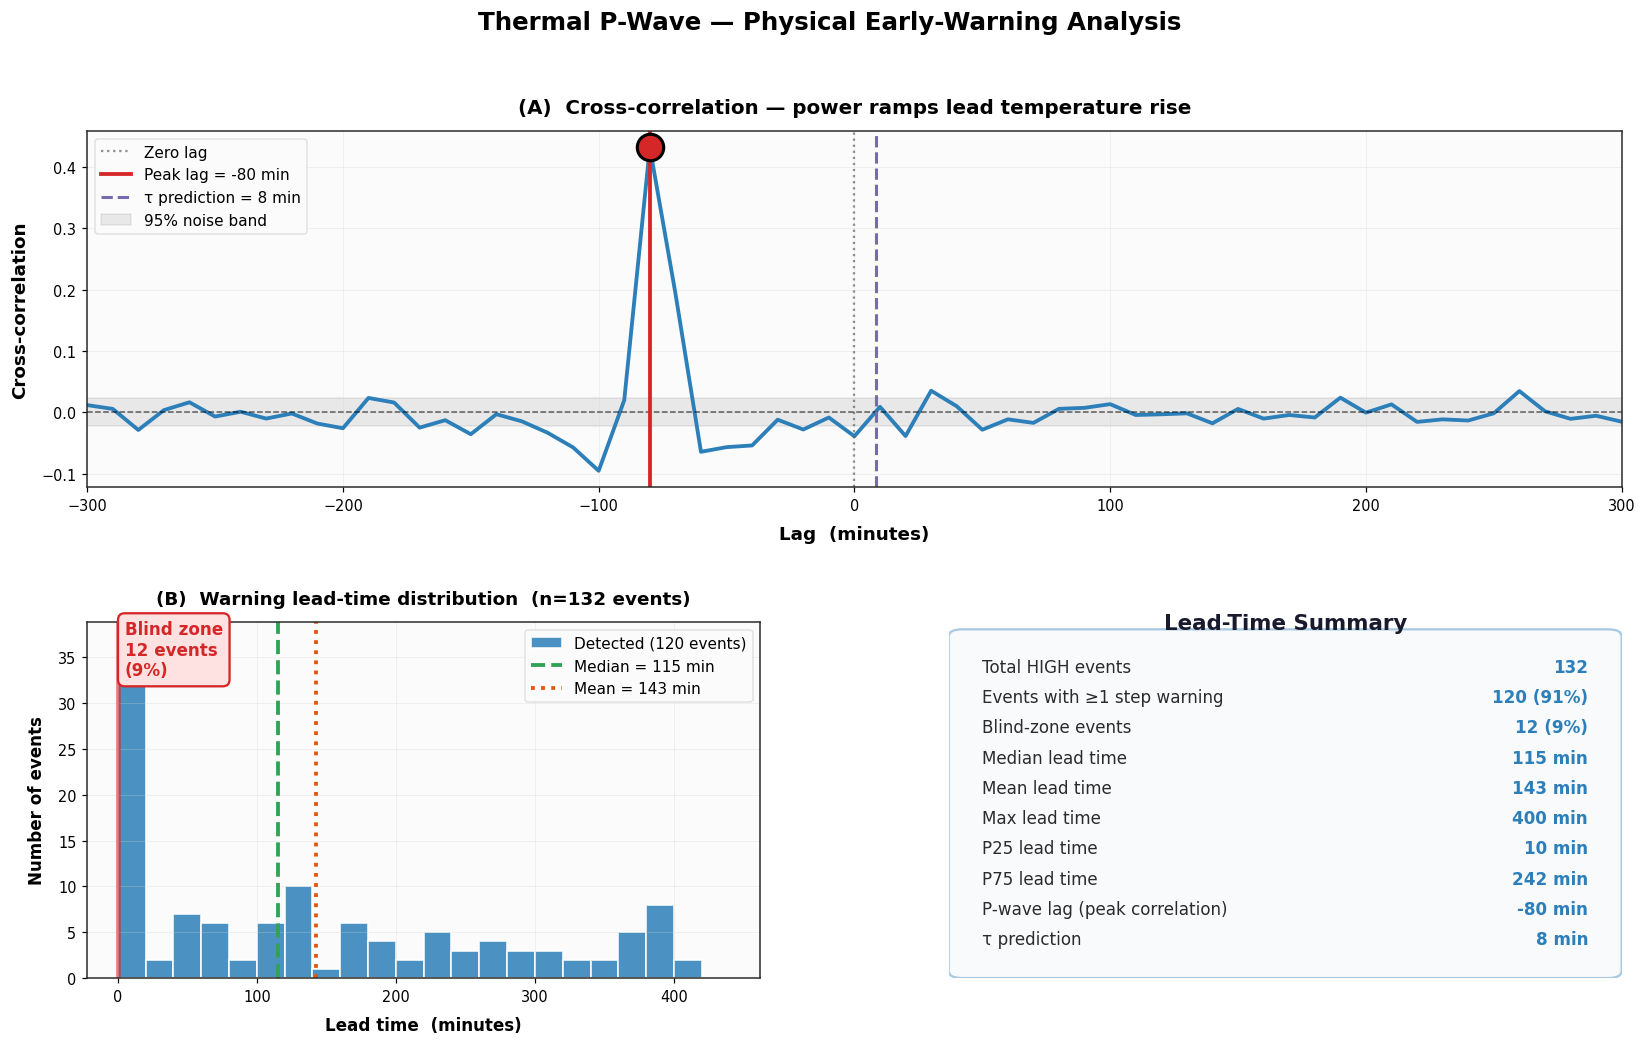


THERMAL P-WAVE — early-warning analysis
Peak cross-correlation lag       : -80 min
τ (thermal time constant)        : 8 min
Total HIGH events                : 132
Events detected with warning     : 120 (91%)
Blind-zone events                : 12
Median lead time                 : 115 min


In [10]:
# ═══════════════════════════════════════════════════════════════════════
# THERMAL P-WAVE ANALYSIS
# Earthquakes: fast P-wave arrives before damaging S-wave.
# Here: power ramps (P-wave) precede temperature rise (S-wave).
# Measure the physical lag and derive theoretical warning lead time.
# ═══════════════════════════════════════════════════════════════════════

# ─── Cross-correlation between power-change and temperature-change ───
power = test["compute_power"].values
d_power = np.diff(power)
d_T = np.diff(T_obs)

# Normalize
d_power_n = (d_power - d_power.mean()) / (d_power.std() + 1e-9)
d_T_n     = (d_T - d_T.mean()) / (d_T.std() + 1e-9)

# Cross-correlation
xcorr = correlate(d_T_n, d_power_n, mode="full") / len(d_T_n)
lags  = correlation_lags(len(d_T_n), len(d_power_n), mode="full")

# Restrict to plausible lags (-30 to +30 steps = ±5 hours)
mask = (lags >= -30) & (lags <= 30)
lags_m = lags[mask]
xcorr_m = xcorr[mask]

# Find peak (which lag gives highest correlation)
peak_idx = np.argmax(np.abs(xcorr_m))
peak_lag = lags_m[peak_idx]
peak_corr = xcorr_m[peak_idx]

# ─── Theoretical P-wave lag from α and τ ───
tau_steps = TAU_MIN / DT_MIN
theoretical_lag = tau_steps  # ~1α time constant

# ─── Blind-zone analysis ───
# For each HIGH event in baseline, how many steps of advance warning
# does the ML model provide?
def event_onsets(T, threshold):
    over = T > threshold
    diff = np.diff(np.r_[0, over.astype(int), 0])
    starts = np.flatnonzero(diff == 1)
    return starts

baseline_onsets = event_onsets(run_baseline["T_sim"], HIGH_THRESH)

lead_times = []
for onset in baseline_onsets:
    # Find first step before onset where ML forecast crosses threshold
    lookback = 40  # 400 min = ~6.6 hours
    lo = max(0, onset - lookback)
    forecast_window = T_ml[lo:onset]
    triggers = np.flatnonzero(forecast_window > HIGH_THRESH)
    if len(triggers) > 0:
        lead = onset - (lo + triggers[0])
        lead_times.append(lead * DT_MIN)  # minutes
    else:
        lead_times.append(0)

lead_times = np.array(lead_times)

# ═══════════════════════════════════════════════════════════════════════
# FIGURE — 3 panels
# ═══════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 2, hspace=0.38, wspace=0.28,
                       height_ratios=[1.0, 1.0])

# ─── (A) Cross-correlation ───
ax = fig.add_subplot(gs[0, :])
ax.plot(lags_m * DT_MIN, xcorr_m, lw=2.5, color=PALETTE["primary"])
ax.axhline(0, color="black", lw=1, ls="--", alpha=0.6)
ax.axvline(0, color=PALETTE["neutral"], lw=1.5, ls=":", alpha=0.7,
           label="Zero lag")
ax.axvline(peak_lag * DT_MIN, color=PALETTE["danger"], lw=2.5,
           label=f"Peak lag = {peak_lag * DT_MIN:.0f} min")
ax.axvline(theoretical_lag * DT_MIN, color=PALETTE["purple"], lw=2, ls="--",
           label=f"τ prediction = {theoretical_lag * DT_MIN:.0f} min")

# Shade significant region
sig = 1.96 / np.sqrt(len(d_T_n))
ax.fill_between(lags_m * DT_MIN, -sig, sig, color=PALETTE["neutral"],
                alpha=0.12, label=f"95% noise band")

ax.scatter([peak_lag * DT_MIN], [peak_corr], s=300, c=PALETTE["danger"],
           edgecolor="black", linewidth=2, zorder=10)

ax.set_xlabel("Lag  (minutes)", fontsize=12, fontweight="bold")
ax.set_ylabel("Cross-correlation", fontsize=12, fontweight="bold")
ax.set_title("(A)  Cross-correlation — power ramps lead temperature rise",
             fontsize=13, fontweight="bold", pad=12)
ax.legend(loc="upper left", fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(-300, 300)

# ─── (B) Lead-time distribution ───
ax = fig.add_subplot(gs[1, 0])
n_zero = (lead_times == 0).sum()
n_nonzero = (lead_times > 0).sum()

# Histogram
bins = np.arange(0, 450, 20)
ax.hist(lead_times[lead_times > 0], bins=bins,
        color=PALETTE["primary"], edgecolor="white", linewidth=1.2,
        alpha=0.85, label=f"Detected ({n_nonzero} events)")
ax.axvline(0, color=PALETTE["danger"], lw=3, alpha=0.6)
ax.text(5, ax.get_ylim()[1] * 0.85,
        f"Blind zone\n{n_zero} events\n({n_zero/len(lead_times)*100:.0f}%)",
        fontsize=11, fontweight="bold", color=PALETTE["danger"],
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#fee2e2",
                  edgecolor=PALETTE["danger"], linewidth=1.5))

# Stats
median_lead = np.median(lead_times[lead_times > 0])
mean_lead   = lead_times[lead_times > 0].mean()
ax.axvline(median_lead, color=PALETTE["success"], lw=2.5, ls="--",
           label=f"Median = {median_lead:.0f} min")
ax.axvline(mean_lead, color=PALETTE["accent"], lw=2.5, ls=":",
           label=f"Mean = {mean_lead:.0f} min")

ax.set_xlabel("Lead time  (minutes)", fontsize=11, fontweight="bold")
ax.set_ylabel("Number of events", fontsize=11, fontweight="bold")
ax.set_title(f"(B)  Warning lead-time distribution  (n={len(lead_times)} events)",
             fontsize=12, fontweight="bold")
ax.legend(loc="upper right", fontsize=10)
ax.grid(True, alpha=0.3)

# ─── (C) Blind-zone / coverage summary ───
ax = fig.add_subplot(gs[1, 1])
ax.axis("off")

# Build summary card
metrics = [
    ("Total HIGH events",             f"{len(lead_times)}"),
    ("Events with ≥1 step warning",   f"{n_nonzero} ({n_nonzero/len(lead_times)*100:.0f}%)"),
    ("Blind-zone events",             f"{n_zero} ({n_zero/len(lead_times)*100:.0f}%)"),
    ("Median lead time",              f"{median_lead:.0f} min"),
    ("Mean lead time",                f"{mean_lead:.0f} min"),
    ("Max lead time",                 f"{lead_times.max():.0f} min"),
    ("P25 lead time",                 f"{np.percentile(lead_times[lead_times>0], 25):.0f} min"),
    ("P75 lead time",                 f"{np.percentile(lead_times[lead_times>0], 75):.0f} min"),
    ("P-wave lag (peak correlation)", f"{peak_lag * DT_MIN:.0f} min"),
    ("τ prediction",                  f"{theoretical_lag * DT_MIN:.0f} min"),
]

ax.text(0.5, 0.98, "Lead-Time Summary",
        ha="center", fontsize=14, fontweight="bold",
        color=PALETTE["navy"], transform=ax.transAxes)

y_pos = 0.86
for label, value in metrics:
    ax.text(0.05, y_pos, label, ha="left", fontsize=11,
            color="#2b2b2b", transform=ax.transAxes)
    ax.text(0.95, y_pos, value, ha="right", fontsize=11,
            fontweight="bold", color=PALETTE["primary"], transform=ax.transAxes)
    y_pos -= 0.085

ax.add_patch(FancyBboxPatch((0.02, 0.02), 0.96, 0.94,
                             boxstyle="round,pad=0.02",
                             facecolor="#f0f4f8", alpha=0.4,
                             edgecolor=PALETTE["primary"], linewidth=1.5,
                             transform=ax.transAxes, zorder=0))

plt.suptitle("Thermal P-Wave — Physical Early-Warning Analysis",
             fontsize=16, fontweight="bold", y=0.99)
save_fig("06_thermal_p_wave")
plt.show()

print("\n" + "=" * 72)
print("THERMAL P-WAVE — early-warning analysis")
print("=" * 72)
print(f"Peak cross-correlation lag       : {peak_lag * DT_MIN:.0f} min")
print(f"τ (thermal time constant)        : {theoretical_lag * DT_MIN:.0f} min")
print(f"Total HIGH events                : {len(lead_times)}")
print(f"Events detected with warning     : {n_nonzero} ({n_nonzero/len(lead_times)*100:.0f}%)")
print(f"Blind-zone events                : {n_zero}")
print(f"Median lead time                 : {median_lead:.0f} min")

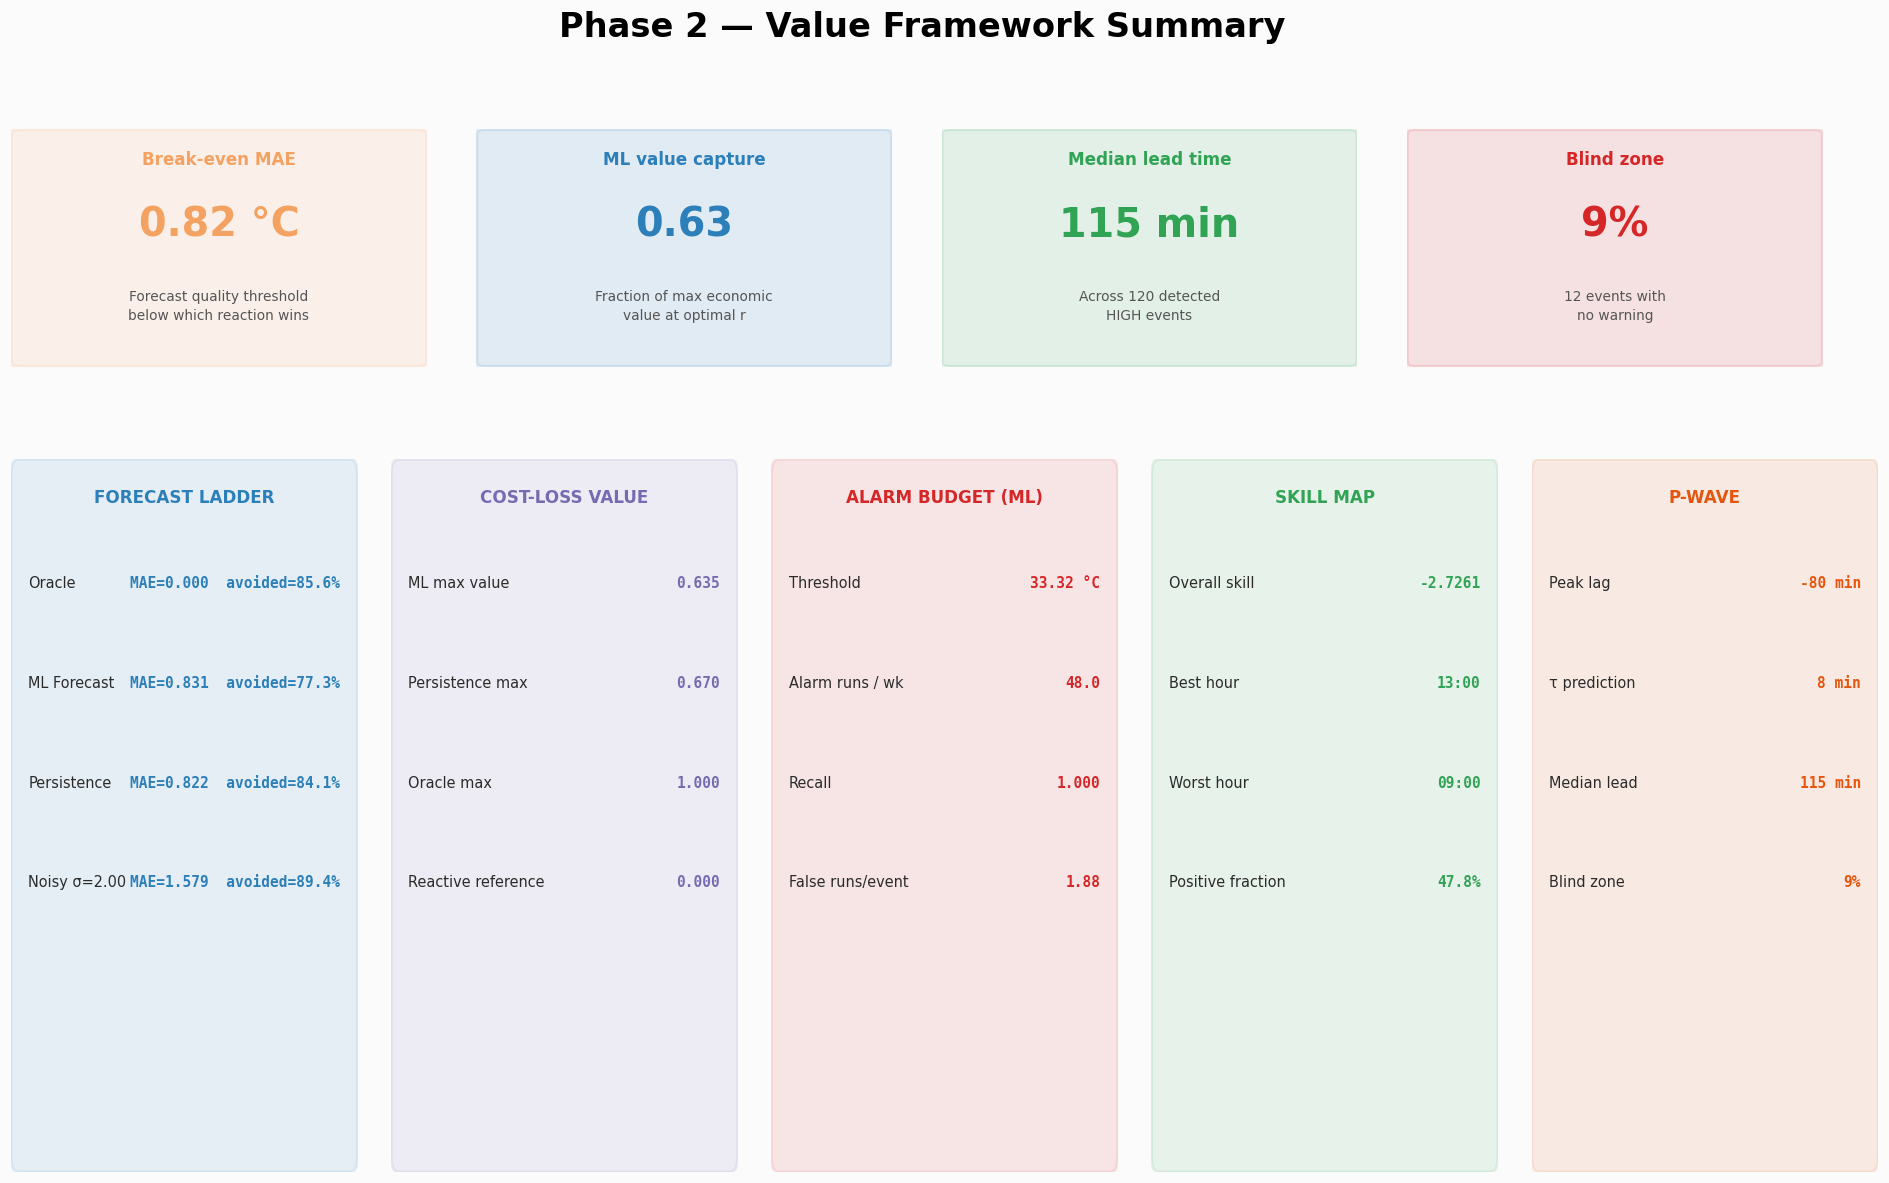


PHASE 2 COMPLETE — Value Framework established
✓ Forecast Value Curve    break-even MAE = 0.82 °C
✓ Cost-loss value         ML captures 63.5% of max economic value
✓ Alarm budget            48.0 alarms/week  recall=1.000
✓ Persistence skill       overall = -2.7261  positive = 47.8% of steps
✓ Thermal P-wave          peak lag = -80 min  median lead = 115 min

Results saved to: ../models/phase2_value_results.json
Figures saved to: ../figures/value/


In [12]:
# ═══════════════════════════════════════════════════════════════════════
# SAVE PHASE 2 RESULTS
# ═══════════════════════════════════════════════════════════════════════

# Build results dict
phase2 = {
    "test_window": {
        "start":       str(test["timestamp"].min()),
        "end":         str(test["timestamp"].max()),
        "steps":       len(test),
        "hours":       test_hours,
        "weeks":       test_weeks,
    },
    "baseline": {
        "events":      base_events,
        "degree_min":  base_dm,
        "pump":        base_pump,
    },
    "reactive": {
        "events":      reactive_events,
        "avoided_%":   reactive_avoided,
        "degree_min":  reactive_dm,
        "dm_reduction_%": reactive_dm_red,
        "pump_overhead_%": reactive_pump_oh,
    },
    "forecast_ladder": [
        {
            "name":  e["name"],
            "MAE":   round(e["MAE"], 4),
            "events": e["events"],
            "events_avoided_%": round(e["events_avoided_%"], 2),
            "degree_min_reduction_%": round(e["degree_min_reduction_%"], 2),
            "pump_overhead_%": round(e["pump_overhead_%"], 2),
        }
        for e in ladder_sorted
    ],
    "value_curve": {
        "break_even_MAE_C":  round(float(break_even), 3) if break_even is not None else None,
        "reactive_avoided_%": round(reactive_avoided, 2),
        "best_forecast_MAE": round(min(maes), 3),
        "best_forecast_avoided_%": round(max(avoided), 2),
    },
    "cost_loss": {
        "ML_max_value":      round(float(val_ml.max()), 3),
        "persist_max_value": round(float(val_persist.max()), 3),
        "oracle_max_value":  round(float(val_oracle.max()), 3),
    },
    "alarm_budget_ML": {
        "threshold":         round(float(ml_point["threshold"]), 3),
        "alarms_per_week":   round(float(ml_point["alarms_per_week"]), 2),
        "recall":            round(float(ml_point["recall"]), 3),
        "false_alarms":      int(ml_point["false_alarms"]),
        "detected":          int(ml_point["detected"]),
    },
    "skill_map": {
        "overall_skill":   round(float(overall), 4),
        "best_hour":       int(best_h),
        "worst_hour":      int(worst_h),
        "ramp_up_skill":   round(float(ramp_skill.loc["ramping up", "mean"]), 4),
        "steady_skill":    round(float(ramp_skill.loc["steady", "mean"]), 4),
        "ramp_down_skill": round(float(ramp_skill.loc["ramping down", "mean"]), 4),
        "positive_skill_fraction": round(float((df["skill"] > 0).mean()), 4),
    },
    "p_wave": {
        "peak_lag_min":    int(peak_lag * DT_MIN),
        "tau_min":         int(theoretical_lag * DT_MIN),
        "median_lead_min": int(median_lead),
        "mean_lead_min":   int(mean_lead),
        "n_events":        int(len(lead_times)),
        "n_blind_zone":    int(n_zero),
        "blind_zone_%":    round(n_zero / len(lead_times) * 100, 1),
    },
}

with open(MODEL_DIR / "phase2_value_results.json", "w") as f:
    json.dump(phase2, f, indent=2, default=str)

# ═══════════════════════════════════════════════════════════════════════
# NAME-BASED LOOKUPS (fix for indices)
# ═══════════════════════════════════════════════════════════════════════
def _get(name):
    return next(e for e in ladder if e["name"] == name)

_oracle = _get("Oracle")
_ml     = _get("ML Forecast")
_pers   = _get("Persistence")

# Find the noisiest oracle by max MAE
_noisy = max((e for e in ladder if e["name"].startswith("Oracle +")),
             key=lambda x: x["MAE"])
_noisy_label = f"Noisy σ={_noisy['sigma']:.2f}"

# ═══════════════════════════════════════════════════════════════════════
# PHASE 2 SUMMARY CARD
# ═══════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor("#fbfbfc")
fig.suptitle("Phase 2 — Value Framework Summary",
             fontsize=22, fontweight="bold", y=0.98)

# ─── Big number cards ───
big_numbers = [
    ("Break-even MAE",
     f"{break_even:.2f} °C" if break_even is not None else "n/a",
     PALETTE["gold"],
     "Forecast quality threshold\nbelow which reaction wins"),
    ("ML value capture",
     f"{val_ml.max():.2f}",
     PALETTE["primary"],
     "Fraction of max economic\nvalue at optimal r"),
    ("Median lead time",
     f"{median_lead:.0f} min",
     PALETTE["success"],
     f"Across {n_nonzero} detected\nHIGH events"),
    ("Blind zone",
     f"{n_zero/len(lead_times)*100:.0f}%",
     PALETTE["danger"],
     f"{n_zero} events with\nno warning"),
]

for i, (label, value, color, subtitle) in enumerate(big_numbers):
    ax = fig.add_axes([0.04 + i * 0.235, 0.71, 0.21, 0.18])
    ax.axis("off")
    ax.add_patch(FancyBboxPatch((0.02, 0.02), 0.96, 0.96,
                                 boxstyle="round,pad=0.02",
                                 facecolor=color, alpha=0.12,
                                 edgecolor=color, linewidth=2.5,
                                 transform=ax.transAxes))
    ax.text(0.5, 0.85, label, ha="center", fontsize=11, fontweight="bold",
            color=color, transform=ax.transAxes)
    ax.text(0.5, 0.55, value, ha="center", fontsize=26, fontweight="bold",
            color=color, transform=ax.transAxes)
    ax.text(0.5, 0.20, subtitle, ha="center", fontsize=9,
            color="#555555", transform=ax.transAxes, linespacing=1.4)

# ─── Detail blocks (fixed: name-based lookup) ───
detail_blocks = [
    ("FORECAST LADDER", [
        ("Oracle",
         f"MAE={_oracle['MAE']:.3f}  avoided={_oracle['events_avoided_%']:.1f}%"),
        ("ML Forecast",
         f"MAE={_ml['MAE']:.3f}  avoided={_ml['events_avoided_%']:.1f}%"),
        ("Persistence",
         f"MAE={_pers['MAE']:.3f}  avoided={_pers['events_avoided_%']:.1f}%"),
        (_noisy_label,
         f"MAE={_noisy['MAE']:.3f}  avoided={_noisy['events_avoided_%']:.1f}%"),
    ], PALETTE["primary"]),

    ("COST-LOSS VALUE", [
        ("ML max value",       f"{val_ml.max():.3f}"),
        ("Persistence max",    f"{val_persist.max():.3f}"),
        ("Oracle max",         f"{val_oracle.max():.3f}"),
        ("Reactive reference", "0.000"),
    ], PALETTE["purple"]),

    ("ALARM BUDGET (ML)", [
        ("Threshold",        f"{ml_point['threshold']:.2f} °C"),
        ("Alarm runs / wk",  f"{ml_point['alarms_per_week']:.1f}"),
        ("Recall",           f"{ml_point['recall']:.3f}"),
        ("False runs/event", f"{ml_point['false_alarms']/max(ml_point['detected'],1):.2f}"),
    ], PALETTE["danger"]),

    ("SKILL MAP", [
        ("Overall skill",    f"{overall:+.4f}"),
        ("Best hour",        f"{best_h:02d}:00"),
        ("Worst hour",       f"{worst_h:02d}:00"),
        ("Positive fraction",f"{(df['skill'] > 0).mean()*100:.1f}%"),
    ], PALETTE["success"]),

    ("P-WAVE", [
        ("Peak lag",     f"{peak_lag * DT_MIN:.0f} min"),
        ("τ prediction", f"{theoretical_lag * DT_MIN:.0f} min"),
        ("Median lead",  f"{median_lead:.0f} min"),
        ("Blind zone",   f"{n_zero/len(lead_times)*100:.0f}%"),
    ], PALETTE["accent"]),
]

for i, (title, items, color) in enumerate(detail_blocks):
    ax = fig.add_axes([0.04 + i * 0.192, 0.10, 0.175, 0.54])
    ax.axis("off")
    ax.add_patch(FancyBboxPatch((0.02, 0.02), 0.96, 0.96,
                                 boxstyle="round,pad=0.02",
                                 facecolor=color, alpha=0.10,
                                 edgecolor=color, linewidth=2,
                                 transform=ax.transAxes))
    ax.text(0.5, 0.94, title, ha="center", fontsize=11, fontweight="bold",
            color=color, transform=ax.transAxes)
    y = 0.82
    for label, value in items:
        ax.text(0.05, y, label, ha="left", fontsize=9.5,
                color="#2b2b2b", transform=ax.transAxes)
        ax.text(0.95, y, value, ha="right", fontsize=9.5, fontweight="bold",
                color=color, family="monospace", transform=ax.transAxes)
        y -= 0.14

save_fig("07_phase2_summary", dpi=180)
plt.show()

# ─── Final printout ───
print()
print("=" * 78)
print("PHASE 2 COMPLETE — Value Framework established")
print("=" * 78)

if break_even is not None:
    print(f"✓ Forecast Value Curve    break-even MAE = {break_even:.2f} °C")
else:
    print("✓ Forecast Value Curve    (no break-even found)")

print(f"✓ Cost-loss value         ML captures {val_ml.max():.1%} of max economic value")
print(f"✓ Alarm budget            {ml_point['alarms_per_week']:.1f} alarms/week  recall={ml_point['recall']:.3f}")
print(f"✓ Persistence skill       overall = {overall:+.4f}  positive = {(df['skill'] > 0).mean()*100:.1f}% of steps")
print(f"✓ Thermal P-wave          peak lag = {peak_lag * DT_MIN:.0f} min  median lead = {median_lead:.0f} min")
print()
print(f"Results saved to: {MODEL_DIR}/phase2_value_results.json")
print(f"Figures saved to: {FIG_DIR}/")